# Anexă cu statistici pentru evaluarea LLM multimodale în șah

&copy; Cemîrtan Cristian, 2025.

GPU utilizat: Intel Arc A580 Challenger 8GB OC

## Definirea funcțiilor pentru generarea de statistici

Importarea bibliotecilor.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

Citirea fișierului ce reprezintă o partidă de șah.

In [2]:
def read_telemetry(filename):
    return pd.read_json('telemetries/' + filename).assign(
        IsElimination=lambda x: x['Move'].map(lambda x: x['IsElimination']),
        Move=lambda x: x['Move'].map(lambda x: x['RawMove']),
        TimeTaken=lambda x: pd.to_timedelta(x['TimeTaken']).dt.total_seconds()
    )

Obținerea metricilor (neasistate de Stockfisn) pentru un jucător.

In [3]:
def get_counts(df):
    return df.loc[df['Model'] != 'Stockfish', ['AttemptCount', 'InvalidMoves', 'WinPercentage', 'TimeTaken']].assign(
        InvalidMoves=lambda x: x['InvalidMoves'].map(len)
    )

Agregarea metricilor.

In [4]:
def describe_counts(df):
    return df.agg(['count', 'average', 'min', 'max', 'sum'])

Obținerea culorii jucătorului după indici din subtabel.

In [5]:
def get_color(df):
    return ('Alb', 'Negru')[df.index[0] & 1]

Afișarea de statistici împreună cu corelații între metrici pentru un jucător.

In [6]:
def display_counts(df):
    if len(df) == 0:
        return
        
    display(Markdown(f'##### Statistici pentru {get_color(df)}'))
    counts_df = describe_counts(df)
    display(counts_df)
    display(df.corr().map(lambda x: f'{x * 100:.2f}%'))

Setarea titlului unui grafic, și afișarea graficului.

In [7]:
def prepare_plot(df, title):
    if plt.gca().get_legend_handles_labels()[1]:
        plt.legend()
    
    plt.xticks(df.index + 1)
    plt.title(f'{title} ({get_color(df)})')
    plt.show()

Decorăm `plt.bar` ca să nu includem datele vide.

In [8]:
old_plt_bar = plt.bar

def temp(*args, **kargs):
    if len(args[0]) > 0 and len(args[1]) > 0:
        old_plt_bar(*args, **kargs)

plt.bar = temp
del temp

Pregătirea graficului ce reprezintă timpul durat pe fiecare pas.

In [9]:
def plot_time_per_step(df):
    stockfish_mask = df['Model'] == 'Stockfish'

    plt.bar(
        df[~stockfish_mask].index + 1,
        df.loc[~stockfish_mask, 'TimeTaken'],
        label='Independent'
    )

    plt.bar(
        df[stockfish_mask].index + 1,
        df.loc[stockfish_mask, 'TimeTaken'],
        label='Asistat de Stockfish'
    )
    
    plt.xlabel('Pași')
    plt.ylabel('Secunde')
    
    prepare_plot(df, 'Timpul durat pe pas')

Pregătirea graficului ce reprezintă nr. de încercări (modelele LLM deseori halucinează cu mișcări ilegale) pe fiecare pas.

In [10]:
def plot_tries_per_step(df):
    authentic_mask = df['Model'] != 'Stockfish'

    plt.bar(
        df[authentic_mask].index + 1,
        df.loc[authentic_mask, 'AttemptCount'],
        label='Încercări'
    )

    plt.bar(
        df[authentic_mask].index + 1,
        df.loc[authentic_mask, 'InvalidMoves'].map(len),
        label='Mișcări invalide'
    )
    
    plt.xlabel('Pași')
    plt.ylabel('Număr')
    
    prepare_plot(df, 'Nr. de încercări pe pas')

Pregătirea graficului ce reprezintă nr. de eliminări pe fiecare pas.

In [11]:
def plot_elimination_per_step(df):
    stockfish_mask = df['Model'] == 'Stockfish'

    plt.bar(
        df[~stockfish_mask].index + 1,
        df.loc[~stockfish_mask, 'IsElimination'].map(lambda x: ('Nu', 'Da')[x]),
        label='Independent'
    )

    plt.bar(
        df[stockfish_mask].index + 1,
        df.loc[stockfish_mask, 'IsElimination'].map(lambda x: ('Nu', 'Da')[x]),
        label='Asistat de Stockfish'
    )
    
    plt.xlabel('Pași')
    plt.ylabel('Eliminare')
    plt.title('Eliminare pe pas')
    
    prepare_plot(df, 'Eliminare pe pas')

Pregătirea graficului ce reprezintă rata de câștig pe fiecare pas.

In [12]:
def plot_winrate_per_step(player_df, opponent_df):
    stockfish_mask = player_df['Model'] == 'Stockfish'

    plt.bar(
        player_df[~stockfish_mask].index + 1,
        player_df.loc[~stockfish_mask, 'WinPercentage'],
        label='Independent'
    )

    plt.bar(
        player_df[stockfish_mask].index + 1,
        player_df.loc[stockfish_mask, 'WinPercentage'],
        label='Intervenit de Stockfish'
    )

    plt.bar(
        opponent_df.index + 1,
        100 - opponent_df['WinPercentage'],
        label='După mișcarea oponentului',
        color='black'
    )
    
    plt.xlabel('Pași')
    plt.ylabel('Rata de câștig')
    
    prepare_plot(player_df, 'Rata de câștig pe pas')

Împărțirea tabelului în doi după culorile alb și negru.

In [13]:
def split_telemetry(df):
    return df[(df.index & 1) == 0], df[(df.index & 1) == 1]

Ușurează afișarea de statistici/grafici pentru fiecare capitol.

In [14]:
def plot_telemetry(filename, restrict_color=''):
    df = read_telemetry(filename)
    display(Markdown('#### Lista mișcărilor'))
    display(df)
    
    df = split_telemetry(df)    
    restrict_color = restrict_color.lower()
    
    callbacks = (
        lambda x: display_counts(get_counts(x)),
        plot_time_per_step,
        plot_tries_per_step,
        plot_elimination_per_step,
        plot_winrate_per_step
    )

    display(Markdown('#### Statistici'))

    for callback in callbacks:
        for i, table in enumerate(df):
            match (i, restrict_color):
                case (0, 'black') | (1, 'white'):
                    continue
            
            if callback is plot_winrate_per_step:
                callback(df[i], df[1 - i])
                continue

            callback(table)

## Qwen vs Qwen

### Ambele neajustate

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,50.956703,False
1,qwen2.5vl:32b-q8_0,d7d5,1,[],42.688631,25.524077,False
2,qwen2.5vl:32b-q8_0,f2f4,1,[],36.703734,14.983956,False
3,qwen2.5vl:32b-q8_0,e7e5,1,[],53.125687,15.011180,False
4,qwen2.5vl:32b-q8_0,g2g3,4,"[e1g1, f2f3, e2e4]",34.592504,46.218656,False
5,qwen2.5vl:32b-q8_0,d8f6,1,[],48.435627,15.034410,False
6,qwen2.5vl:32b-q8_0,g1f3,3,"[g5f7, g2g4]",44.317434,35.832560,False
7,qwen2.5vl:32b-q8_0,f8e7,1,[],27.963063,14.989309,False
8,qwen2.5vl:32b-q8_0,d2d4,6,"[g1f3, d1f3, g2g3, f2f3]",47.700324,67.075885,False
9,Stockfish,e5d4,1,[],49.631799,89.285004,True


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,11.000000,11.000000,11.000000,11.000000
average,3.454545,2.181818,39.757686,43.834884
min,1.000000,0.000000,11.174781,14.983956
max,7.000000,5.000000,61.656374,77.522083
sum,38.000000,24.000000,437.334547,482.183727


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,98.74%,-15.49%,84.26%
InvalidMoves,98.74%,100.00%,-14.30%,80.14%
WinPercentage,-15.49%,-14.30%,100.00%,2.21%
TimeTaken,84.26%,80.14%,2.21%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,13.000000,13.000000,13.000000,13.000000
average,2.538462,1.230769,24.392112,31.860425
min,1.000000,0.000000,2.351628,14.989309
max,8.000000,5.000000,53.125687,87.911710
sum,33.000000,16.000000,317.097450,414.185520


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,96.31%,-43.78%,99.12%
InvalidMoves,96.31%,100.00%,-41.72%,95.11%
WinPercentage,-43.78%,-41.72%,100.00%,-41.03%
TimeTaken,99.12%,95.11%,-41.03%,100.00%


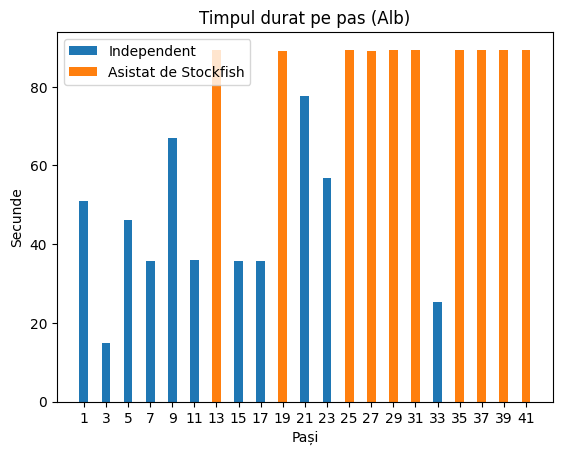

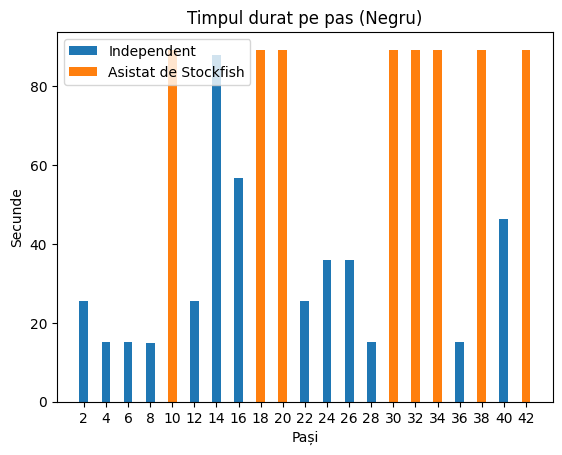

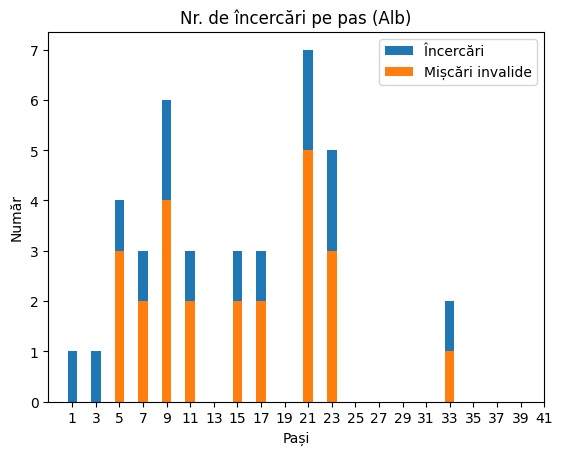

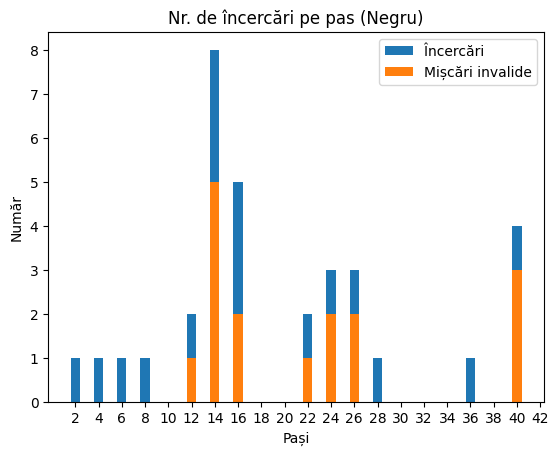

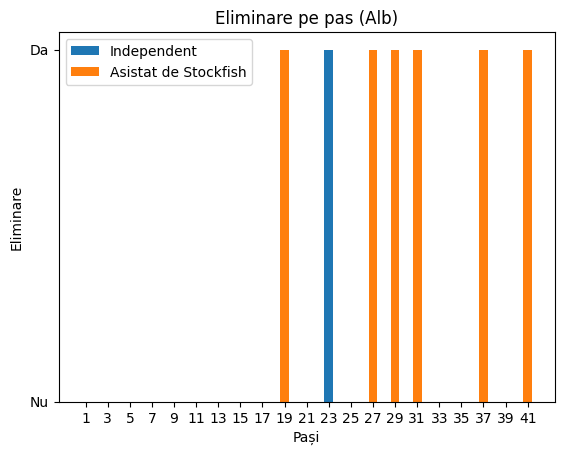

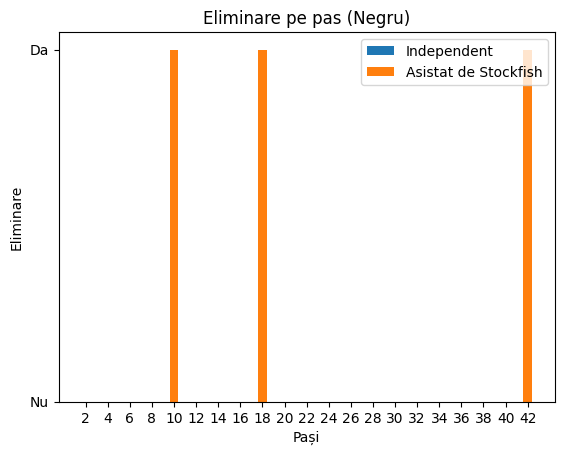

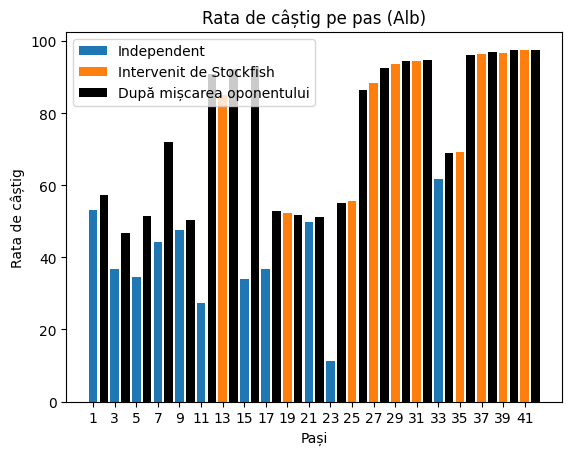

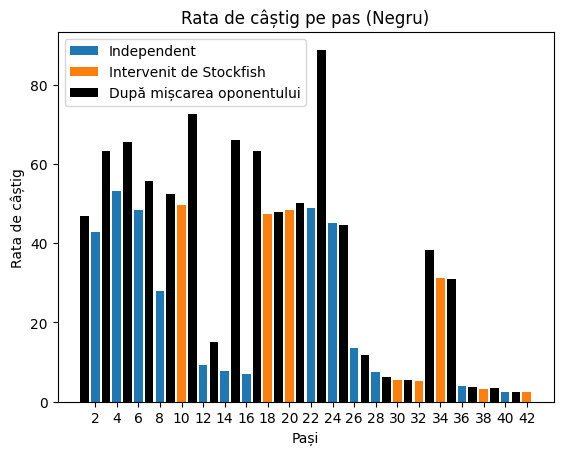

In [15]:
plot_telemetry('qwen vs qwen both stock.json')

### Ambele ajustate cu memorizare de mișcări anterioare

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,39.783797,False
1,qwen2.5vl:32b-q8_0,e7e5,3,"[e8e7, f8h6]",46.966016,33.399577,False
2,qwen2.5vl:32b-q8_0,d2d3,2,[e2e4],48.803552,23.518315,False
3,qwen2.5vl:32b-q8_0,d7d5,1,[],50.092052,13.945605,False
4,qwen2.5vl:32b-q8_0,g1f3,1,[],49.815897,14.009236,False
5,qwen2.5vl:32b-q8_0,d5d4,1,[],34.260021,13.972908,False
6,qwen2.5vl:32b-q8_0,f3e5,2,[d3d5],65.988334,23.558232,True
7,Stockfish,g8e7,1,[],34.842861,81.856098,False
8,qwen2.5vl:32b-q8_0,e5d7,4,"[d3d4, d3e4]",18.707186,42.530680,False
9,Stockfish,e8d7,1,[],75.386856,81.800343,True


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,11.000000,11.000000,11.000000,11.000000
average,2.727273,1.363636,46.399152,33.100925
min,1.000000,0.000000,5.661988,13.993625
max,7.000000,5.000000,96.672486,72.789260
sum,30.000000,15.000000,510.390671,364.110175


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,99.00%,-35.68%,91.68%
InvalidMoves,99.00%,100.00%,-30.66%,90.71%
WinPercentage,-35.68%,-30.66%,100.00%,-31.90%
TimeTaken,91.68%,90.71%,-31.90%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,8.00,8.000,8.000000,8.000000
average,3.75,2.125,30.003322,40.175820
min,1.00,0.000,2.455256,13.945605
max,7.00,5.000,70.986849,70.897006
sum,30.00,17.000,240.026574,321.406558


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,90.82%,-50.56%,100.00%
InvalidMoves,90.82%,100.00%,-71.92%,90.97%
WinPercentage,-50.56%,-71.92%,100.00%,-50.57%
TimeTaken,100.00%,90.97%,-50.57%,100.00%


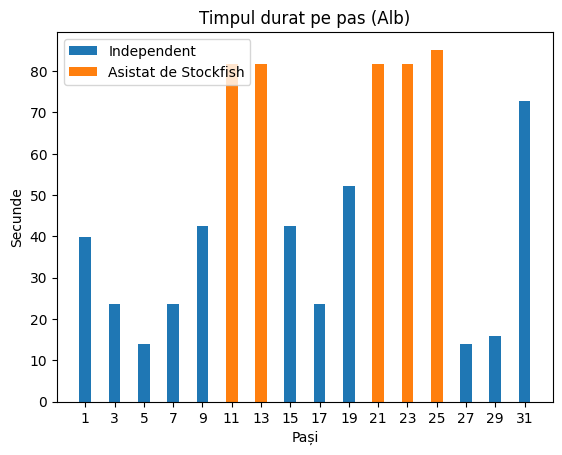

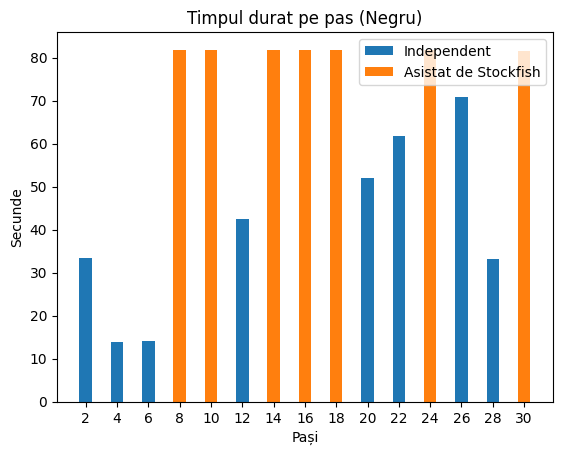

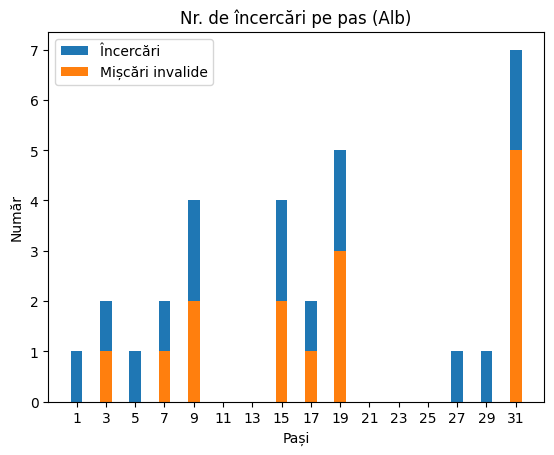

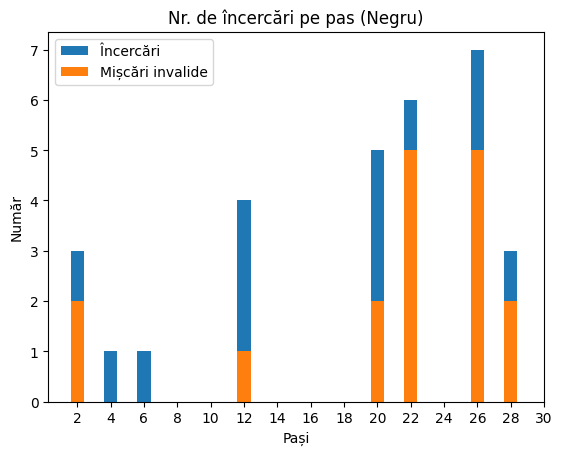

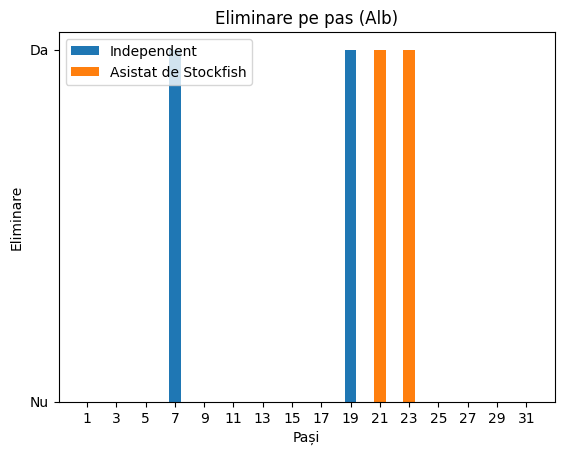

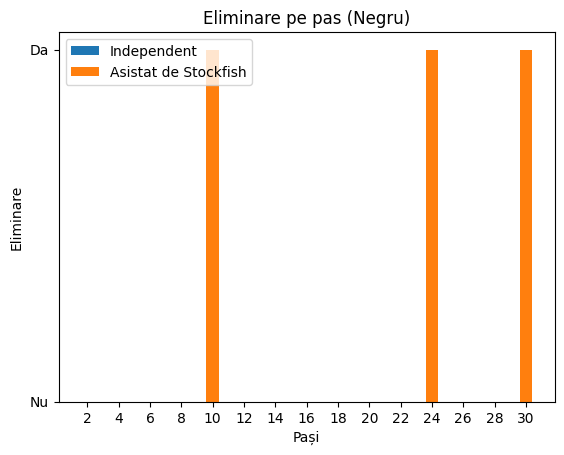

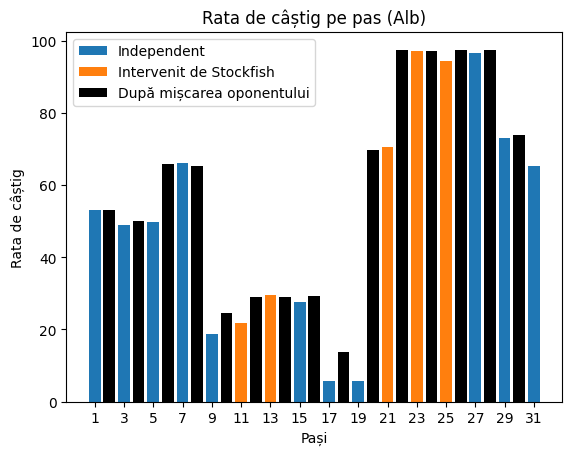

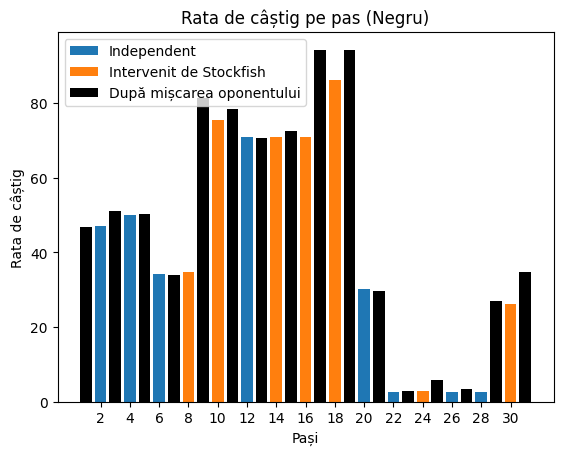

In [16]:
plot_telemetry('qwen vs qwen both with step recall.json')

### Ambele ajustate cu reinforcement după mișcările greșite

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,b1c3,1,[],50.552290,13.986862,False
1,qwen2.5vl:32b-q8_0,d7d5,1,[],49.355672,13.995404,False
2,qwen2.5vl:32b-q8_0,c3d5,1,[],19.677806,13.999993,True
3,Stockfish,d8d5,1,[],78.887952,127.470529,True
4,Stockfish,f2f3,1,[],18.208443,123.995114,False
5,qwen2.5vl:32b-q8_0,e7e5,1,[],80.147016,13.979654,False
6,qwen2.5vl:32b-q8_0,d2d4,4,"[e1f1, f2f3]",14.771074,81.534327,False
7,qwen2.5vl:32b-q8_0,d5d4,4,"[f5f4, f5f3]",84.806846,81.695230,True
8,qwen2.5vl:32b-q8_0,e2e4,4,"[d2d4, d2d3]",9.697119,81.745411,False
9,qwen2.5vl:32b-q8_0,f7f5,6,"[d5e4, d5c4, d5d4, e5f6]",82.279901,103.257749,False


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,7.0,7.000000,7.000000,7.000000
average,3.0,1.142857,23.026028,60.280935
min,1.0,0.000000,9.697119,13.986862
max,4.0,2.000000,50.552290,81.745411
sum,21.0,8.000000,161.182197,421.966542


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,91.69%,-66.53%,99.05%
InvalidMoves,91.69%,100.00%,-73.88%,90.92%
WinPercentage,-66.53%,-73.88%,100.00%,-64.99%
TimeTaken,99.05%,90.92%,-64.99%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,8.0,8.00,8.000000,8.000000
average,3.5,1.75,57.807079,67.201439
min,1.0,0.00,12.640874,13.979654
max,7.0,5.00,84.806846,113.621205
sum,28.0,14.00,462.456635,537.611513


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,98.46%,23.50%,95.24%
InvalidMoves,98.46%,100.00%,31.07%,88.45%
WinPercentage,23.50%,31.07%,100.00%,8.96%
TimeTaken,95.24%,88.45%,8.96%,100.00%


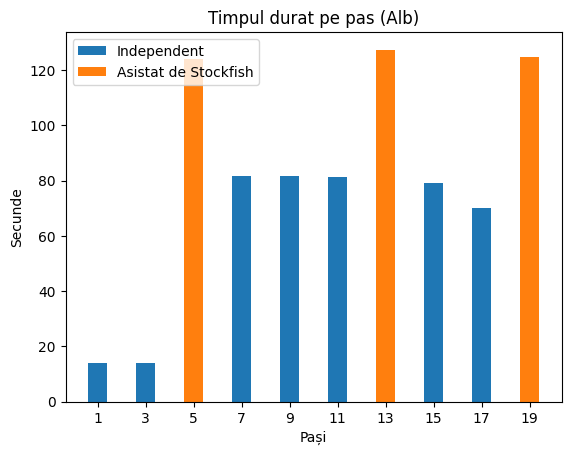

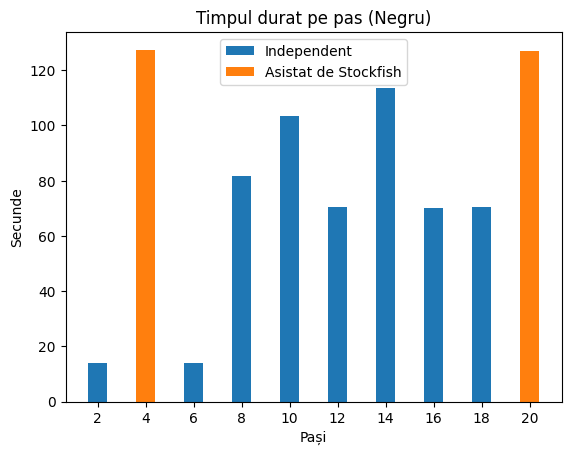

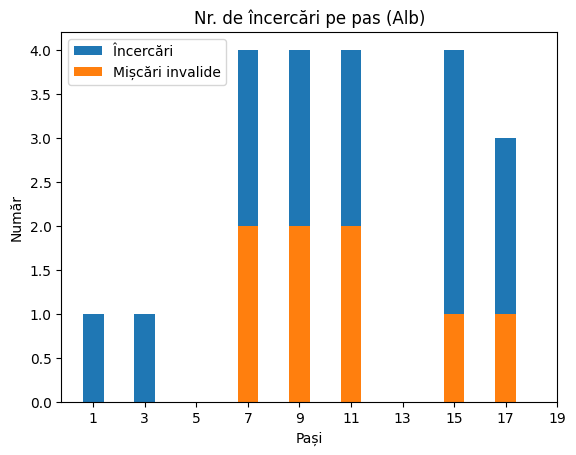

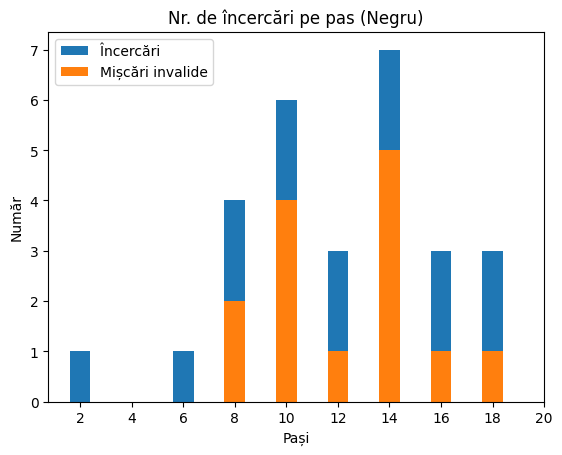

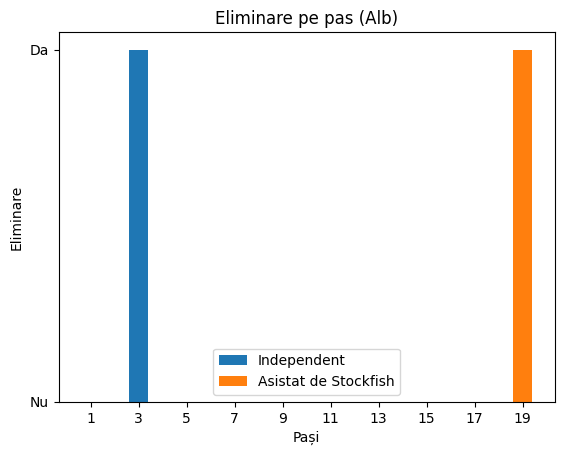

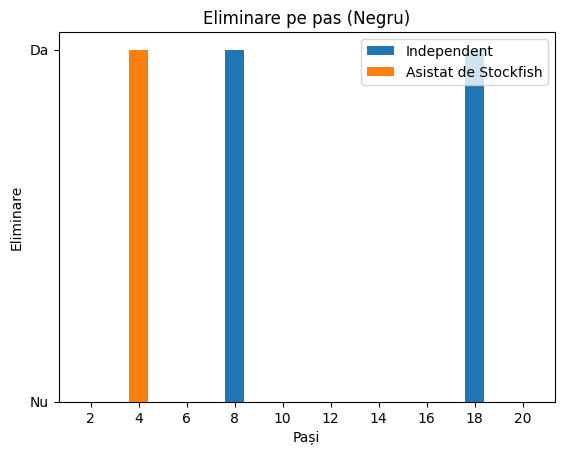

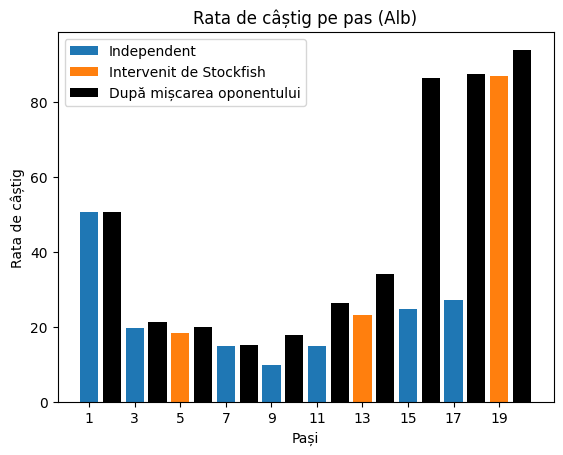

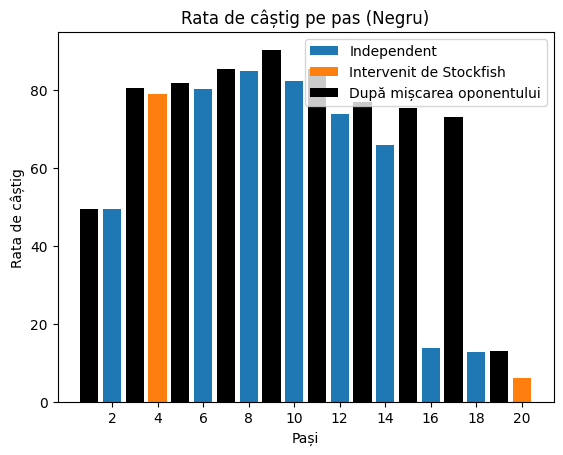

In [17]:
plot_telemetry('qwen vs qwen both with reinforcement.json')

### Ambele ajustate cu memorizare de mișcări anterioare + reinforcement după mișcările greșite

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,48.261466,False
1,qwen2.5vl:32b-q8_0,d7d5,1,[],42.688631,23.718613,False
2,qwen2.5vl:32b-q8_0,e4e5,1,[],49.631799,23.746049,False
3,qwen2.5vl:32b-q8_0,d5d4,1,[],47.700324,23.766278,False
4,qwen2.5vl:32b-q8_0,f2f3,1,[],43.410803,23.769199,False
5,qwen2.5vl:32b-q8_0,d4d3,1,[],43.049347,23.725163,False
6,qwen2.5vl:32b-q8_0,f3f4,1,[],41.611282,23.791021,False
7,qwen2.5vl:32b-q8_0,c7c6,3,[d3d2],33.846582,95.821774,False
8,qwen2.5vl:32b-q8_0,g2g3,1,[],30.396910,24.670468,False
9,qwen2.5vl:32b-q8_0,g8f6,1,[],31.339753,24.691163,False


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,9.0,9.000000,9.000000,9.000000
average,2.0,0.444444,29.502111,49.745876
min,1.0,0.000000,2.455256,23.746049
max,8.0,3.000000,53.125687,158.377885
sum,18.0,4.000000,265.518998,447.712886


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,99.89%,-46.76%,96.28%
InvalidMoves,99.89%,100.00%,-48.05%,97.16%
WinPercentage,-46.76%,-48.05%,100.00%,-45.41%
TimeTaken,96.28%,97.16%,-45.41%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,6.000000,6.0,6.000000,6.000000
average,1.833333,0.5,40.840127,51.002000
min,1.000000,0.0,31.339753,23.718613
max,4.000000,2.0,47.700324,114.289008
sum,11.000000,3.0,245.040764,306.011998


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,98.92%,6.14%,99.48%
InvalidMoves,98.92%,100.00%,14.80%,96.91%
WinPercentage,6.14%,14.80%,100.00%,-0.57%
TimeTaken,99.48%,96.91%,-0.57%,100.00%


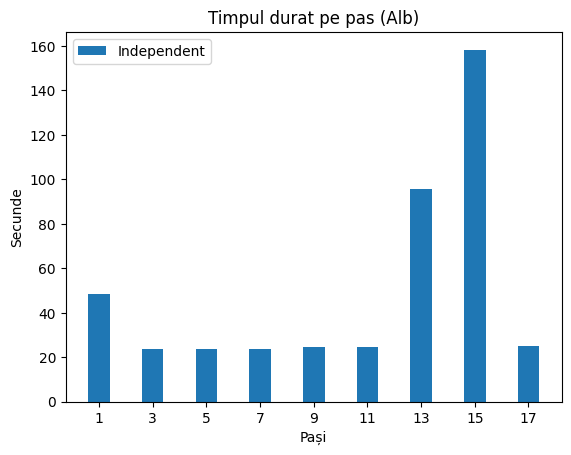

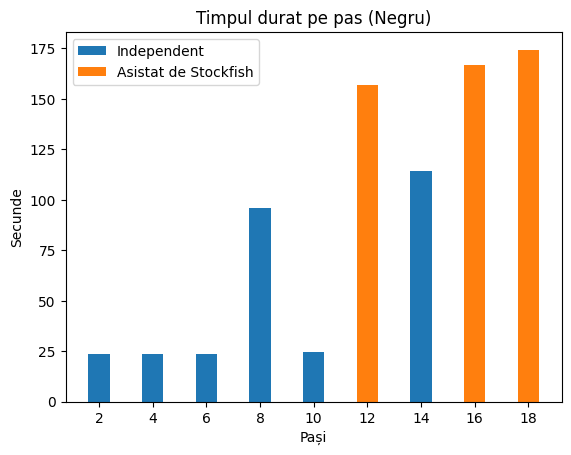

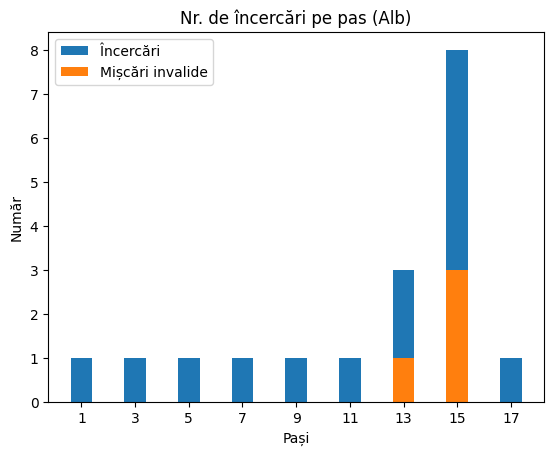

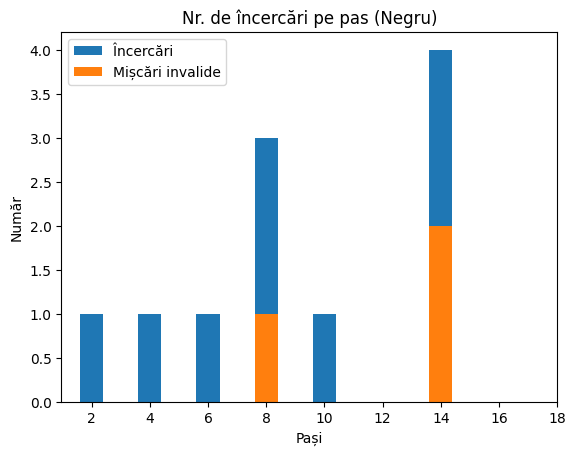

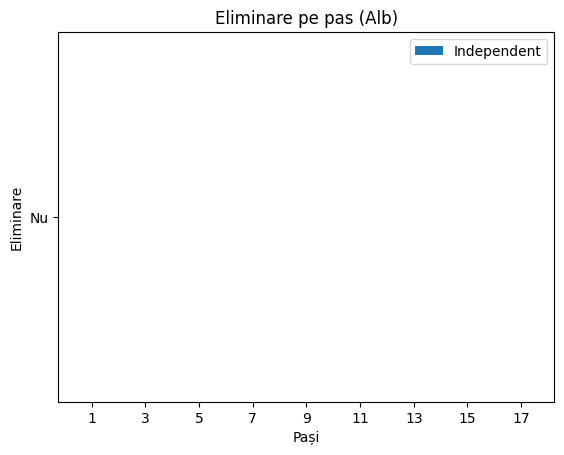

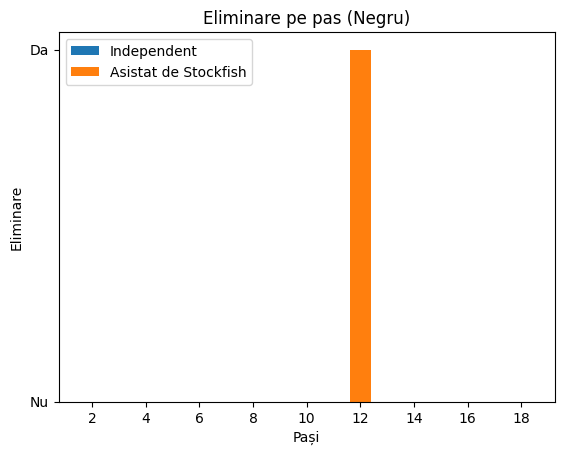

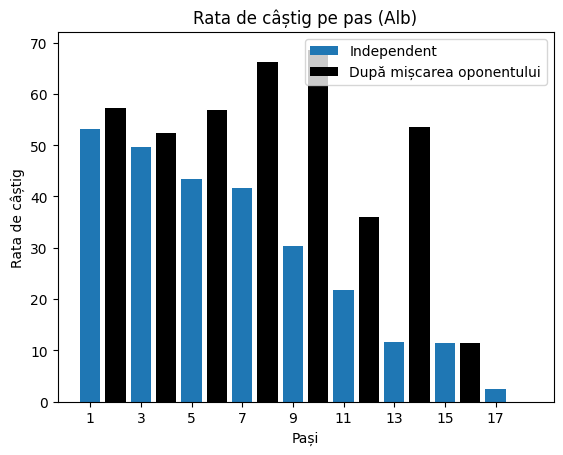

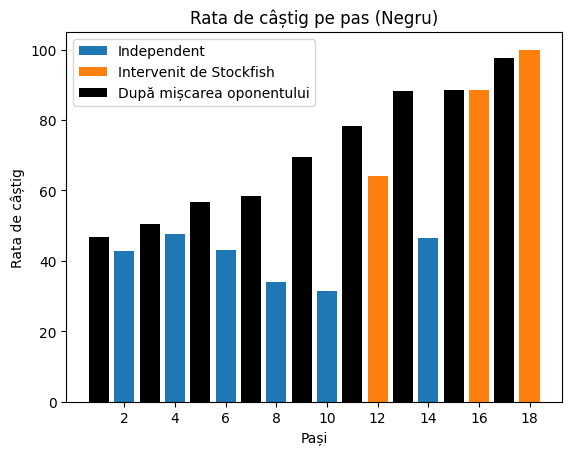

In [18]:
plot_telemetry('qwen vs qwen both with step recall and reinforcement.json')

### Ambele ajustate cu memorizare de mișcări anterioare + informare despre mișcările oponentului

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,51.705515,False
1,qwen2.5vl:32b-q8_0,e7e5,1,[],46.966016,14.155757,False
2,qwen2.5vl:32b-q8_0,f2f3,1,[],43.049347,14.049509,False
3,qwen2.5vl:32b-q8_0,f7f5,1,[],49.355672,14.011321,False
4,qwen2.5vl:32b-q8_0,f3f4,1,[],38.343626,14.001769,False
5,qwen2.5vl:32b-q8_0,g7g5,2,[e5e4],12.004488,23.548254,False
6,qwen2.5vl:32b-q8_0,d2d4,3,"[e4e5, f4f5]",72.036937,33.070194,False
7,qwen2.5vl:32b-q8_0,e8e7,1,[],14.089197,14.052478,False
8,qwen2.5vl:32b-q8_0,d4e5,1,[],82.009879,14.148677,True
9,qwen2.5vl:32b-q8_0,e7e6,1,[],8.453196,14.076615,False


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,16.00,16.000,16.000000,16.000000
average,3.25,1.875,78.729913,37.870150
min,1.00,0.000,38.343626,14.001769
max,8.00,6.000,99.703434,80.674810
sum,52.00,30.000,1259.678600,605.922407


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,98.93%,35.86%,91.24%
InvalidMoves,98.93%,100.00%,35.14%,90.19%
WinPercentage,35.86%,35.14%,100.00%,21.63%
TimeTaken,91.24%,90.19%,21.63%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,14.000000,14.000000,14.000000,14.000000
average,2.928571,1.642857,13.366196,32.482994
min,1.000000,0.000000,2.455256,14.011321
max,8.000000,6.000000,49.355672,80.589064
sum,41.000000,23.000000,187.126743,454.761913


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,97.30%,-44.69%,100.00%
InvalidMoves,97.30%,100.00%,-48.65%,97.31%
WinPercentage,-44.69%,-48.65%,100.00%,-44.78%
TimeTaken,100.00%,97.31%,-44.78%,100.00%


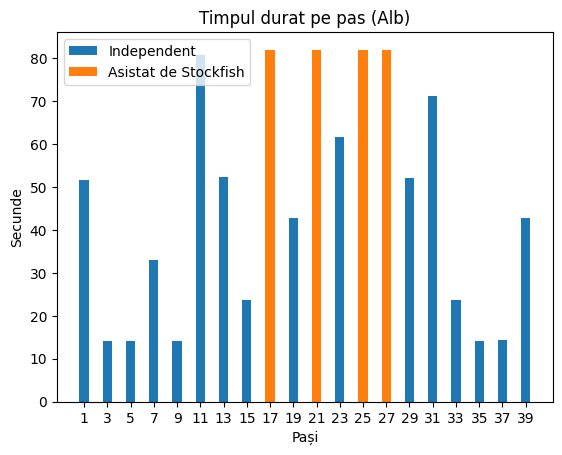

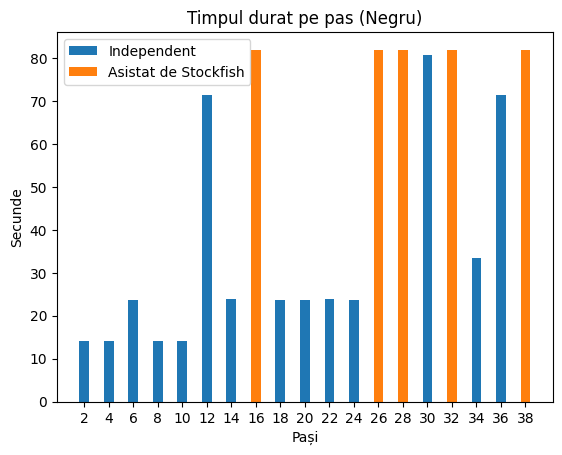

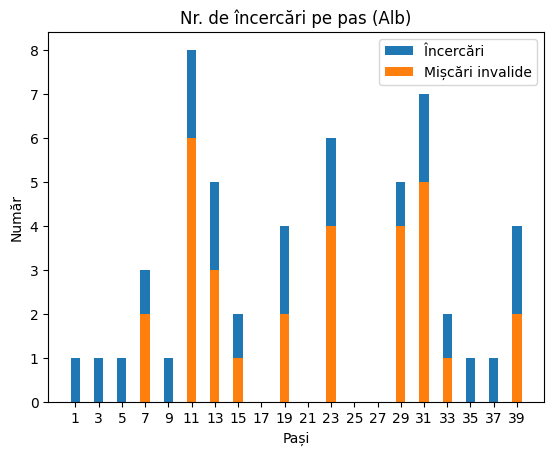

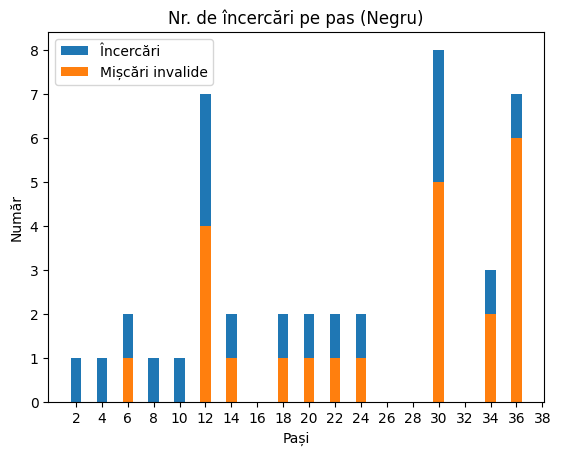

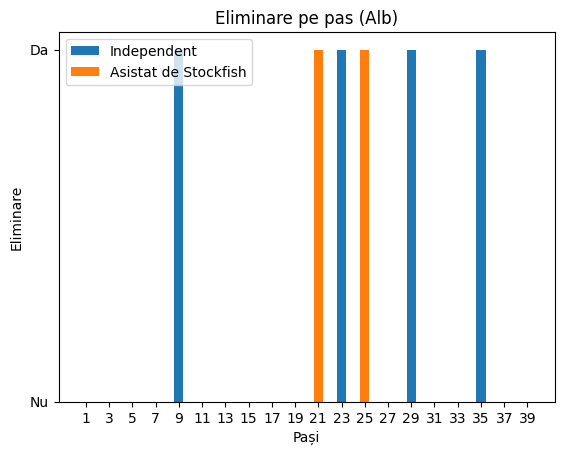

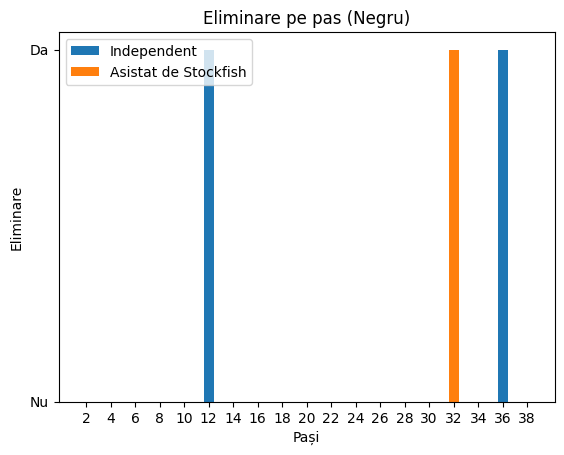

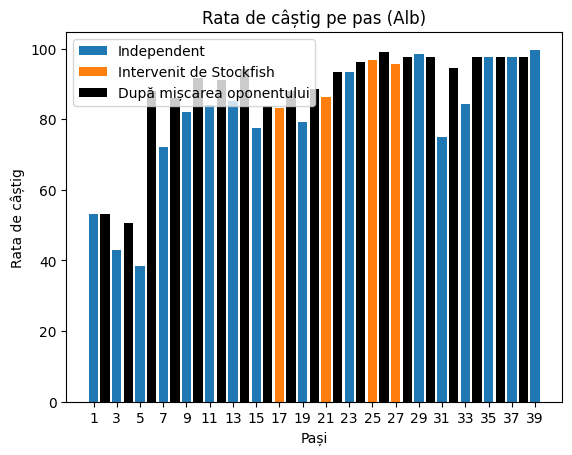

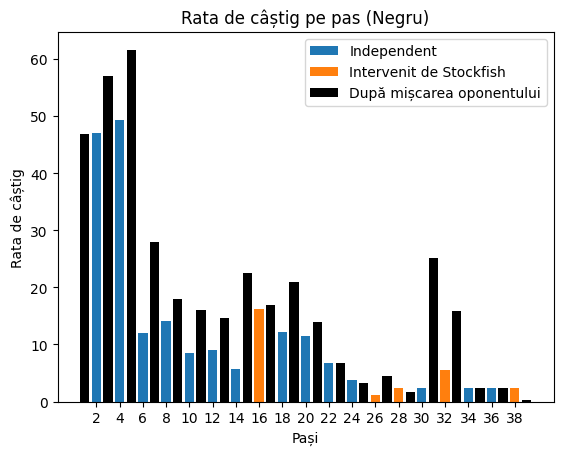

In [19]:
plot_telemetry('qwen vs qwen both with full step recall.json')

### Ambele ajustate cu memorizare de mișcări anterioare + reinforcement după mișcările greșite + informare despre mișcările oponentului

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,51.543113,False
1,qwen2.5vl:32b-q8_0,e7e5,1,[],46.966016,25.172550,False
2,qwen2.5vl:32b-q8_0,f2f3,1,[],43.049347,25.003692,False
3,qwen2.5vl:32b-q8_0,f7f5,1,[],49.355672,25.003200,False
4,qwen2.5vl:32b-q8_0,d2d4,8,[g1f3],47.516641,144.868978,False
5,qwen2.5vl:32b-q8_0,f5f4,3,[f7f6],40.010472,98.412215,False
6,qwen2.5vl:32b-q8_0,d4e5,8,"[e1g1, g1f3, d4f5]",52.850518,159.087196,True
7,Stockfish,d8h4,1,[],45.867111,155.752931,False
8,qwen2.5vl:32b-q8_0,g2g3,3,[f3f4],38.605107,85.771350,False
9,qwen2.5vl:32b-q8_0,e8e7,1,[],5.262854,19.708889,False


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,15.0,15.0,15.000000,15.000000
average,3.8,1.2,79.562426,72.679010
min,1.0,0.0,38.605107,14.009823
max,8.0,3.0,98.205650,159.087196
sum,57.0,18.0,1193.436387,1090.185146


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,88.28%,-5.74%,94.99%
InvalidMoves,88.28%,100.00%,14.29%,83.41%
WinPercentage,-5.74%,14.29%,100.00%,-26.15%
TimeTaken,94.99%,83.41%,-26.15%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,15.000000,15.0,15.000000,15.000000
average,3.866667,1.4,12.322244,68.482228
min,1.000000,0.0,1.755831,14.023521
max,8.000000,4.0,49.355672,122.739408
sum,58.000000,21.0,184.833660,1027.233413


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,94.80%,-46.81%,95.08%
InvalidMoves,94.80%,100.00%,-41.96%,89.11%
WinPercentage,-46.81%,-41.96%,100.00%,-30.04%
TimeTaken,95.08%,89.11%,-30.04%,100.00%


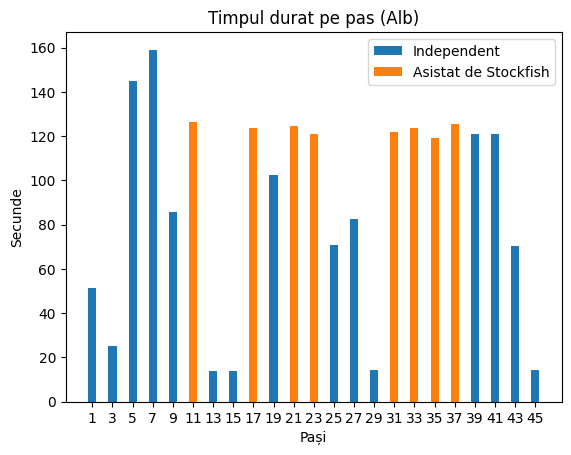

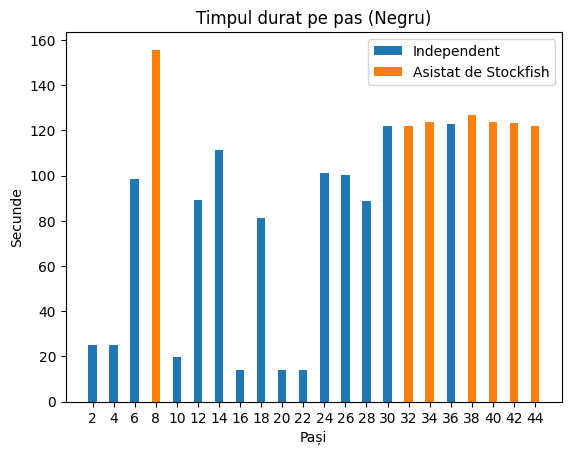

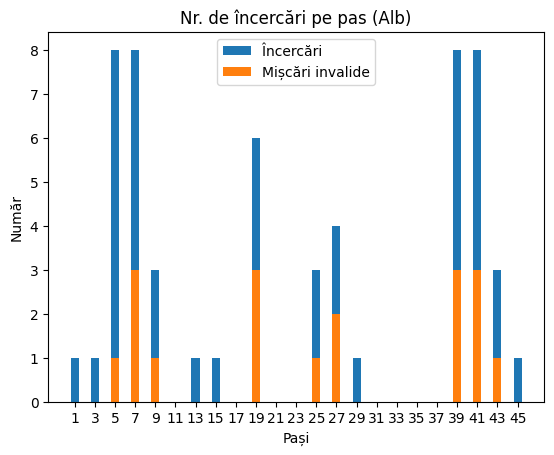

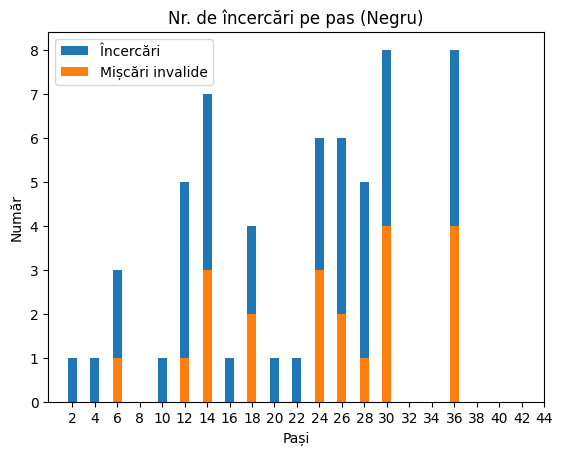

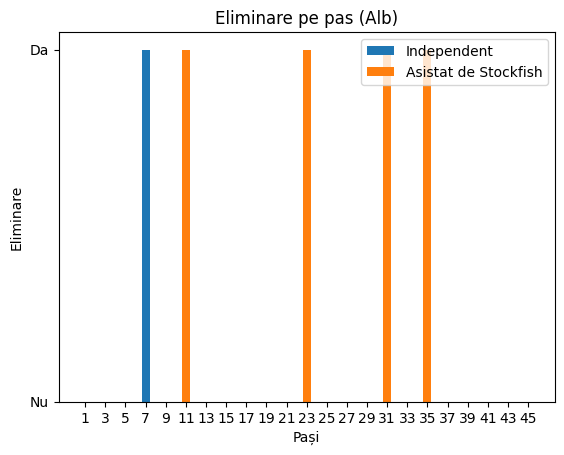

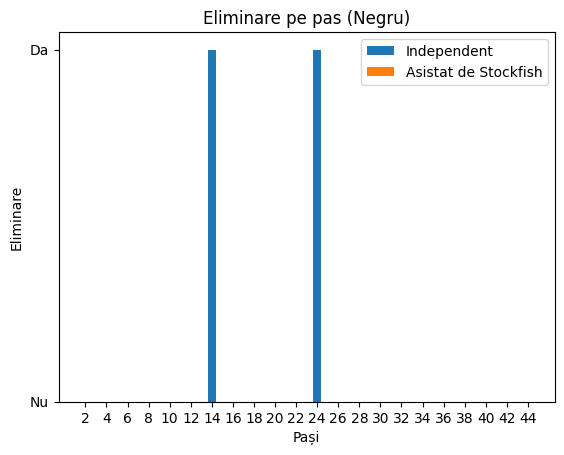

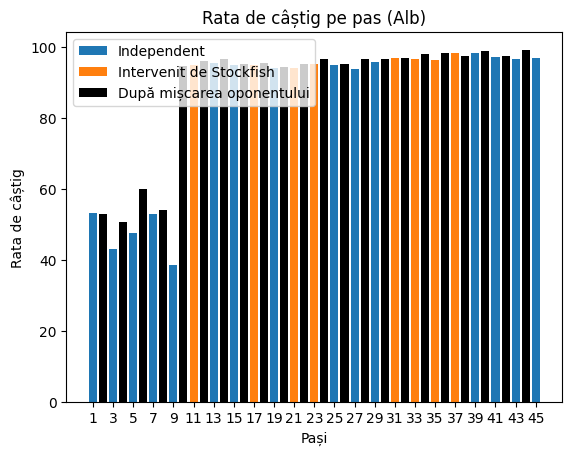

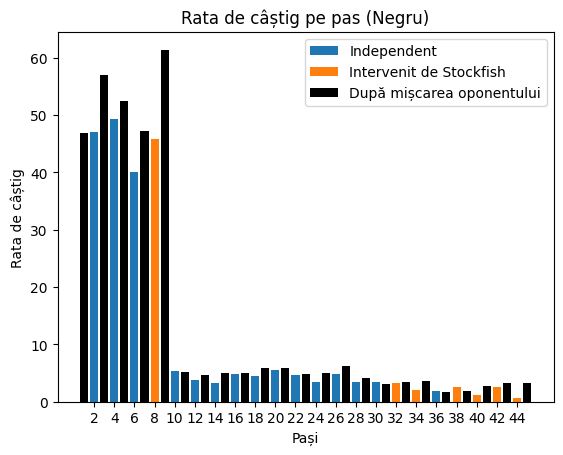

In [20]:
plot_telemetry('qwen vs qwen both with full step recall and reinforcement.json')

## Qwen vs Gemma

### Ambele neajustate

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,14.060332,False
1,Stockfish,c7c5,1,[],47.241245,101.639382,False
2,qwen2.5vl:32b-q8_0,g2g4,1,[],42.508561,42.232911,False
3,Stockfish,e7e6,1,[],54.863331,100.667181,False
4,qwen2.5vl:32b-q8_0,d2d4,1,[],41.343150,41.366217,False
5,Stockfish,d8a5,1,[],39.833847,100.363279,False
6,Stockfish,b1c3,1,[],48.619571,109.988516,False
7,Stockfish,c5d4,1,[],51.288443,100.601870,True
8,qwen2.5vl:32b-q8_0,d1f3,1,[],14.724779,42.276977,False
9,Stockfish,d4c3,1,[],84.326312,102.095094,True


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,6.000000,6.000000,6.000000,6.000000
average,2.166667,0.666667,26.279656,48.432284
min,1.000000,0.000000,2.490778,14.060332
max,7.000000,3.000000,53.125687,98.209003
sum,13.000000,4.000000,157.677937,290.593706


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,98.57%,-62.53%,91.42%
InvalidMoves,98.57%,100.00%,-70.54%,91.84%
WinPercentage,-62.53%,-70.54%,100.00%,-76.80%
TimeTaken,91.42%,91.84%,-76.80%,100.00%


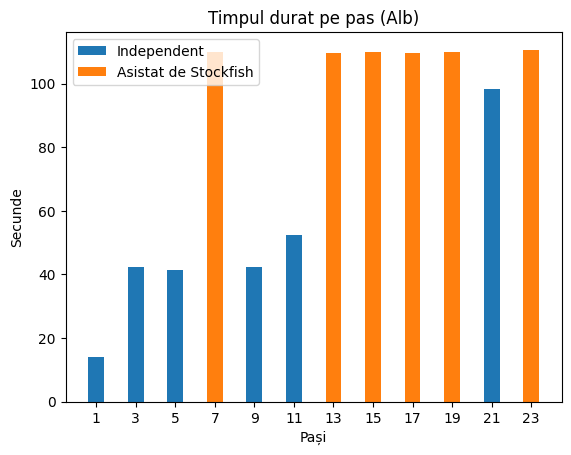

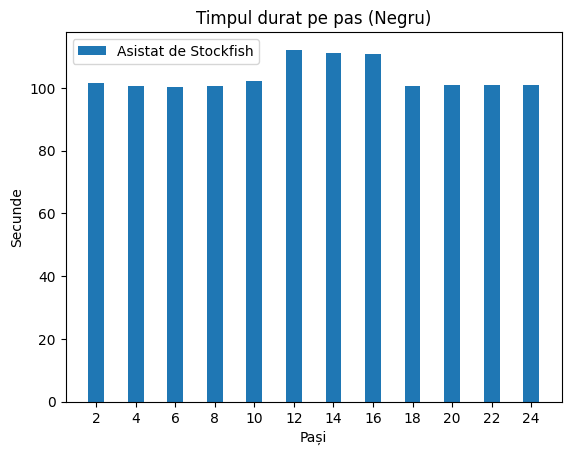

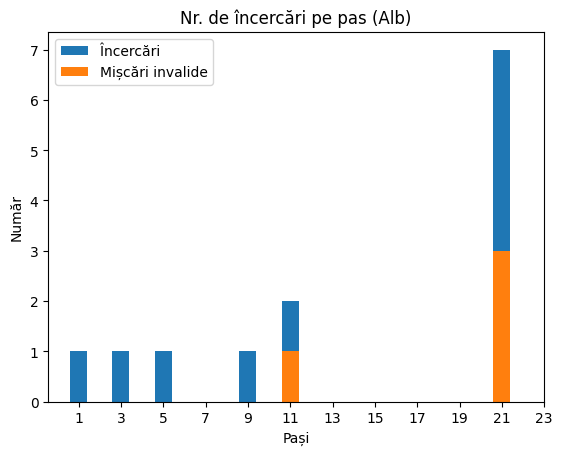

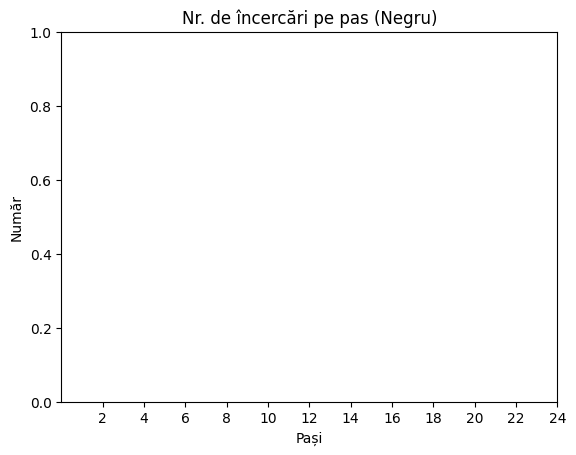

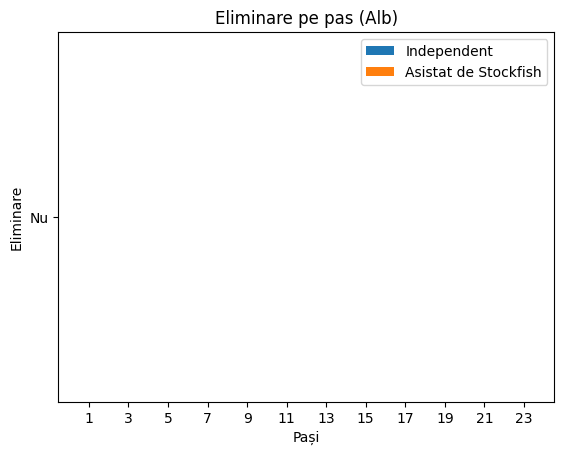

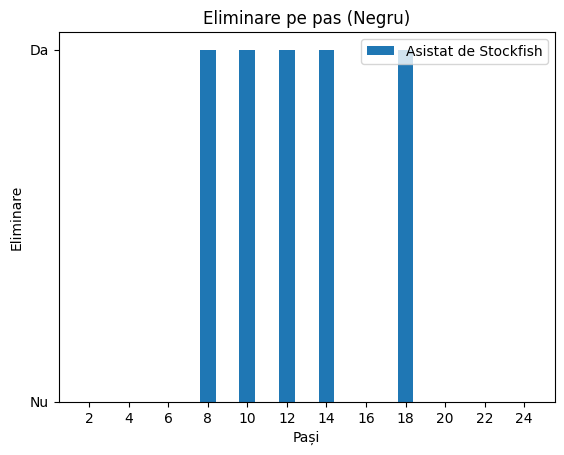

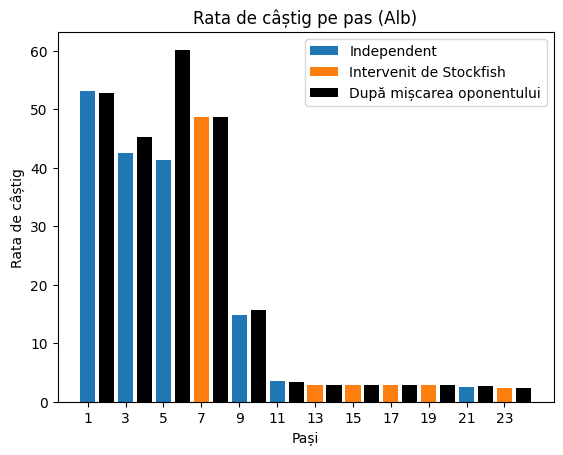

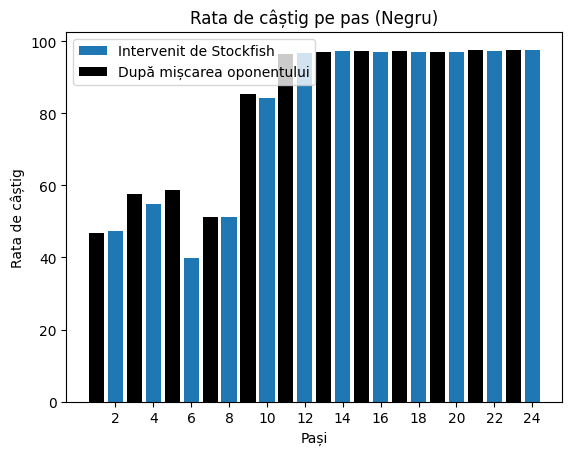

In [21]:
plot_telemetry('qwen vs gemma both stock.json')

### Ambele ajustate cu memorizare de mișcări anterioare + reinforcement după mișcările greșite

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,48.488595,False
1,gemma3:27b-it-q8_0,d7d5,2,[d8e7],43.229985,49.819776,False
2,qwen2.5vl:32b-q8_0,e4e5,1,[],49.631799,51.694124,False
3,gemma3:27b-it-q8_0,c7c5,5,[d5e4],49.907948,74.261824,False
4,qwen2.5vl:32b-q8_0,d1f3,1,[],40.010472,50.521549,False
5,Stockfish,e7e6,1,[],58.567529,99.992200,False
6,Stockfish,f3d1,1,[],40.453162,201.859319,False
7,gemma3:27b-it-q8_0,b8c6,4,[d5e4],60.694424,65.757921,False
8,qwen2.5vl:32b-q8_0,d1f3,1,[],25.233195,51.655187,False
9,Stockfish,c6e5,1,[],75.181318,98.576428,True


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,13.000000,13.000000,13.000000,13.000000
average,2.230769,0.615385,23.422854,71.737073
min,1.000000,0.000000,7.431475,39.604193
max,8.000000,3.000000,53.125687,154.396027
sum,29.000000,8.000000,304.497104,932.581953


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,98.08%,-29.40%,95.55%
InvalidMoves,98.08%,100.00%,-27.92%,96.85%
WinPercentage,-29.40%,-27.92%,100.00%,-17.55%
TimeTaken,95.55%,96.85%,-17.55%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,7.000000,7.000000,7.000000,7.000000
average,3.285714,1.285714,49.125624,59.954100
min,2.000000,1.000000,22.750549,44.849187
max,5.000000,3.000000,75.386856,74.261824
sum,23.000000,9.000000,343.879367,419.678700


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,25.13%,72.93%,95.68%
InvalidMoves,25.13%,100.00%,25.16%,49.33%
WinPercentage,72.93%,25.16%,100.00%,71.16%
TimeTaken,95.68%,49.33%,71.16%,100.00%


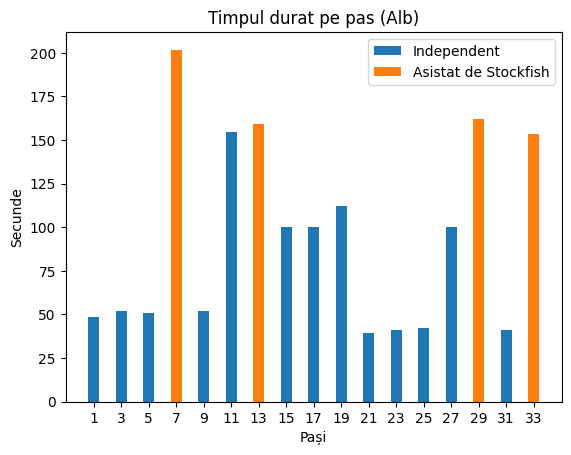

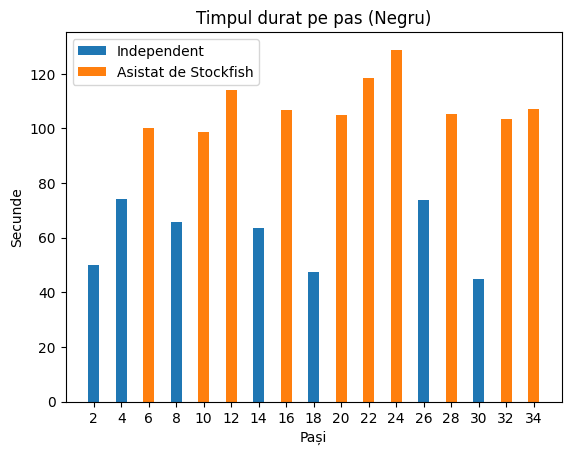

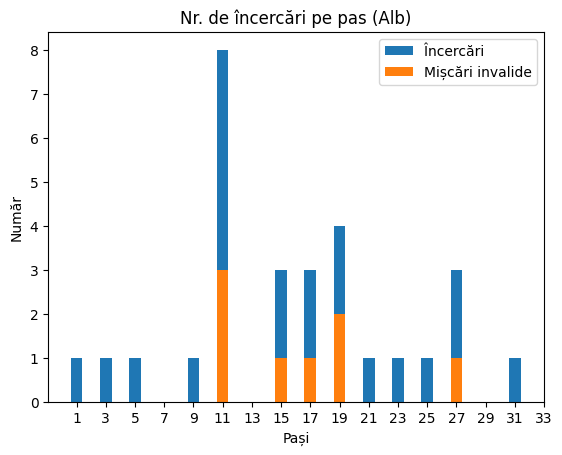

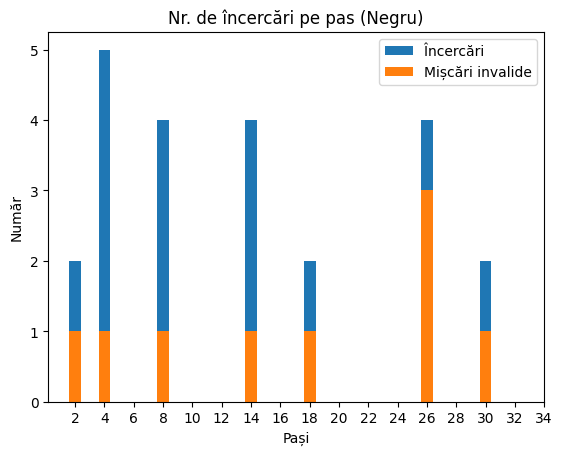

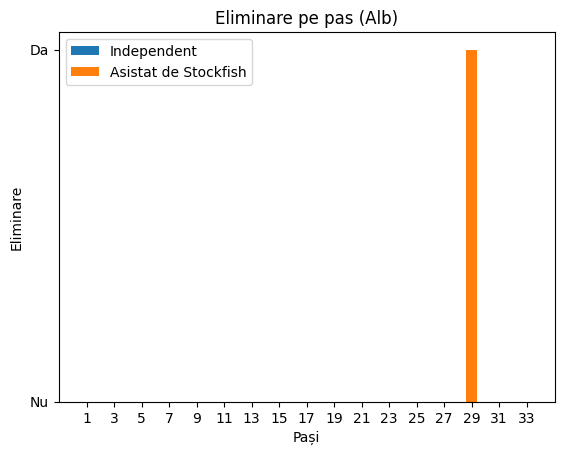

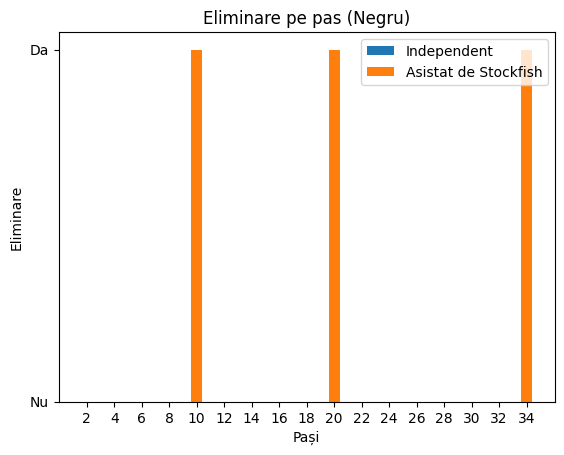

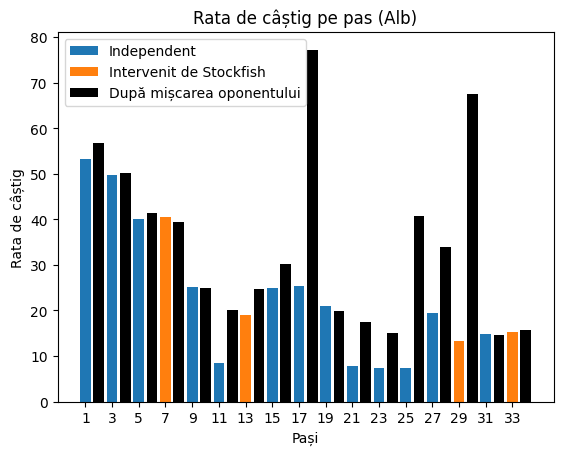

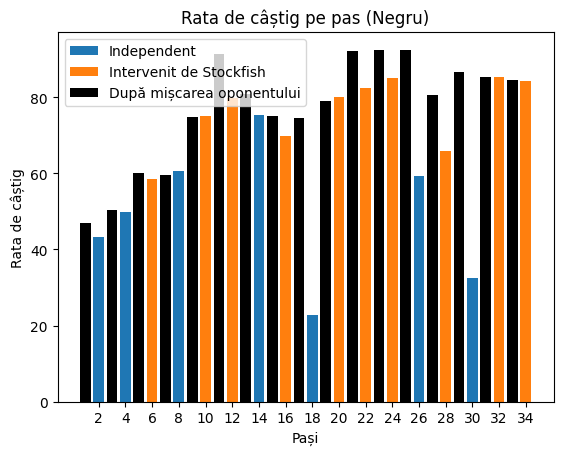

In [22]:
plot_telemetry('qwen vs gemma both with step recall and reinforcement.json')

### Ambele ajustate cu memorizare de mișcări anterioare + informare despre mișcările oponentului

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,d2d4,1,[],52.575175,11.928135,False
1,gemma3:27b-it-q8_0,e7e5,1,[],37.649666,43.326211,False
2,qwen2.5vl:32b-q8_0,d4e5,1,[],61.917183,42.058659,True
3,gemma3:27b-it-q8_0,b8c6,1,[],36.874986,44.253043,False
4,qwen2.5vl:32b-q8_0,f2f3,1,[],47.333026,41.339137,False
5,gemma3:27b-it-q8_0,d8f6,1,[],8.117482,44.222460,False
6,qwen2.5vl:32b-q8_0,f3f4,2,[f3e4],62.350334,51.745450,False
7,gemma3:27b-it-q8_0,f6g5,1,[],8.453196,43.545398,False
8,qwen2.5vl:32b-q8_0,g2g3,1,[],63.977886,42.508722,False
9,gemma3:27b-it-q8_0,g5f4,1,[],8.311810,44.973921,True


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,13.000000,13.000000,13.000000,13.000000
average,2.076923,0.923077,32.322177,49.772341
min,1.000000,0.000000,2.455256,11.928135
max,8.000000,5.000000,63.977886,108.248950
sum,27.000000,12.000000,420.188296,647.040434


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,98.57%,-28.38%,92.71%
InvalidMoves,98.57%,100.00%,-28.42%,91.99%
WinPercentage,-28.38%,-28.42%,100.00%,-34.40%
TimeTaken,92.71%,91.99%,-34.40%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,11.000000,11.000000,11.000000,11.000000
average,1.545455,0.363636,40.001208,48.959460
min,1.000000,0.000000,8.117482,43.326211
max,4.000000,2.000000,97.323968,69.844487
sum,17.000000,4.000000,440.013288,538.554057


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,97.64%,54.68%,99.44%
InvalidMoves,97.64%,100.00%,55.41%,96.75%
WinPercentage,54.68%,55.41%,100.00%,60.29%
TimeTaken,99.44%,96.75%,60.29%,100.00%


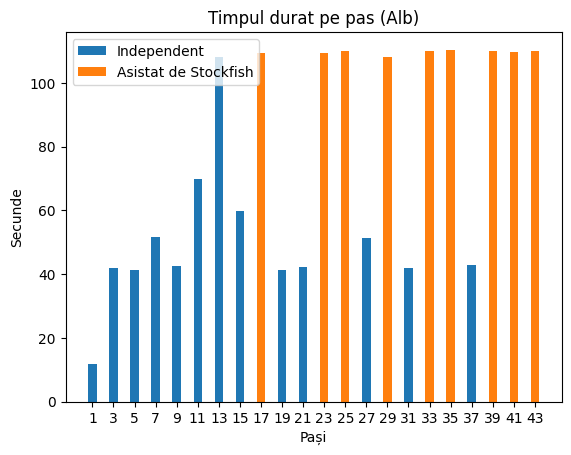

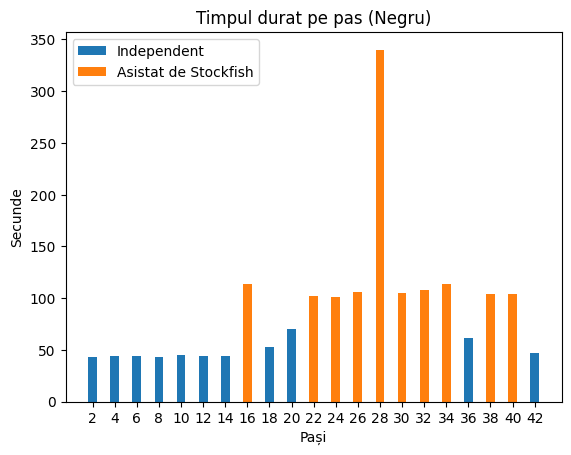

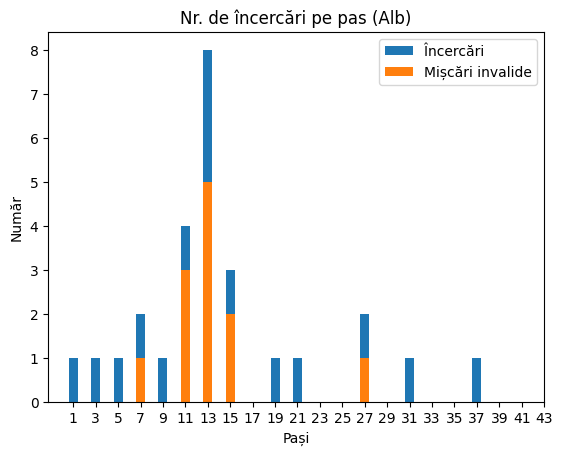

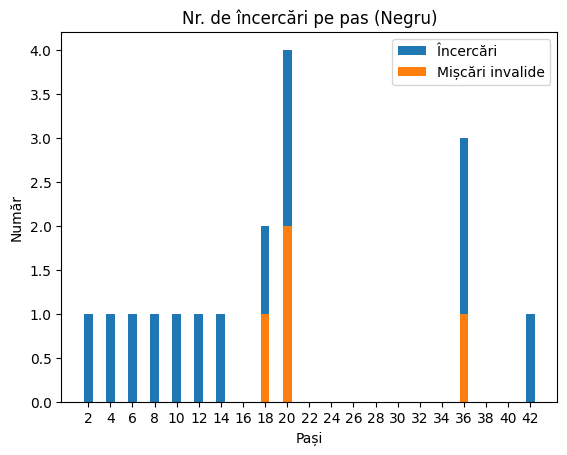

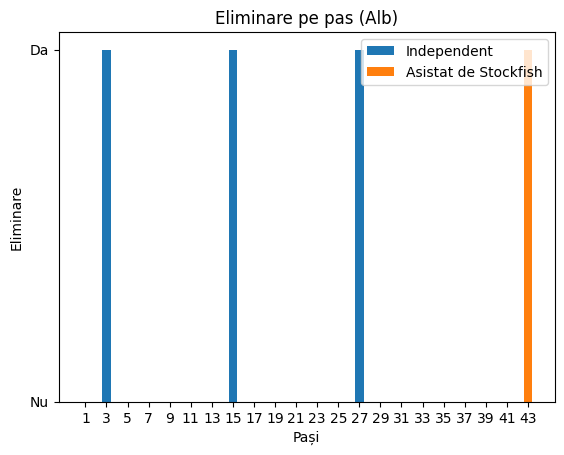

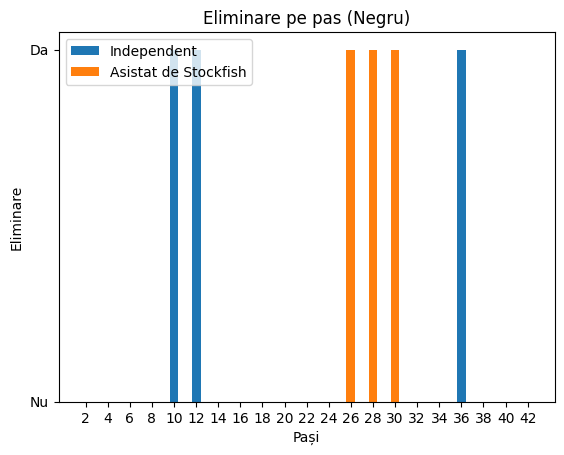

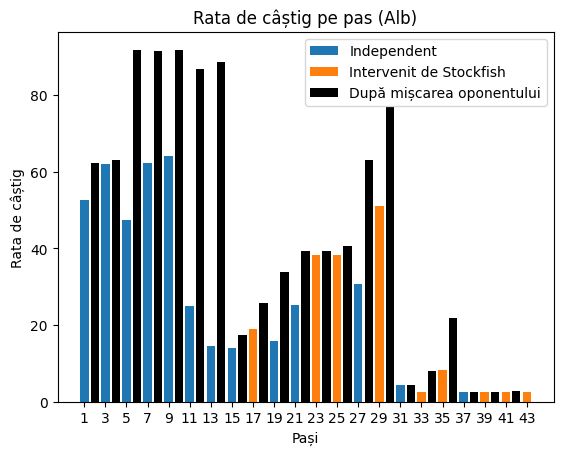

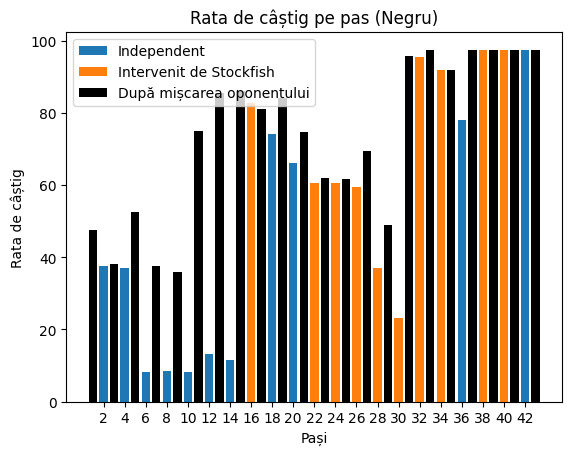

In [23]:
plot_telemetry('qwen vs gemma both with full step recall.json')

### Ambele ajustate cu memorizare de mișcări anterioare + reinforcement după mișcările greșite + informare despre mișcările oponentului

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,49.780073,False
1,gemma3:27b-it-q8_0,e7e5,1,[],46.966016,36.765991,False
2,qwen2.5vl:32b-q8_0,f1b5,1,[],47.516641,52.783663,False
3,Stockfish,c7c6,1,[],51.932129,127.852462,False
4,qwen2.5vl:32b-q8_0,d2d4,3,[f1b5],22.109935,124.586375,False
5,gemma3:27b-it-q8_0,d7d5,2,[b5a4],55.954981,51.000168,False
6,Stockfish,b5e2,1,[],41.611282,186.642121,False
7,gemma3:27b-it-q8_0,d5e4,1,[],57.131106,36.799593,True
8,qwen2.5vl:32b-q8_0,c2c3,1,[],36.107015,53.015735,False
9,gemma3:27b-it-q8_0,d8e7,1,[],57.491439,36.850883,False


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,13.000000,13.000000,13.000000,13.000000
average,2.615385,0.846154,21.860100,85.038211
min,1.000000,0.000000,3.623810,40.800576
max,6.000000,3.000000,53.125687,136.214652
sum,34.000000,11.000000,284.181299,1105.496746


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,91.78%,-51.70%,92.14%
InvalidMoves,91.78%,100.00%,-52.05%,86.73%
WinPercentage,-51.70%,-52.05%,100.00%,-44.92%
TimeTaken,92.14%,86.73%,-44.92%,100.00%


##### Statistici pentru Negru

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,9.000000,9.000000,9.000000,9.000000
average,2.444444,1.111111,71.635982,51.848525
min,1.000000,0.000000,46.966016,36.765991
max,8.000000,4.000000,93.453062,97.371268
sum,22.000000,10.000000,644.723838,466.636727


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,97.12%,61.06%,98.28%
InvalidMoves,97.12%,100.00%,69.13%,99.13%
WinPercentage,61.06%,69.13%,100.00%,62.21%
TimeTaken,98.28%,99.13%,62.21%,100.00%


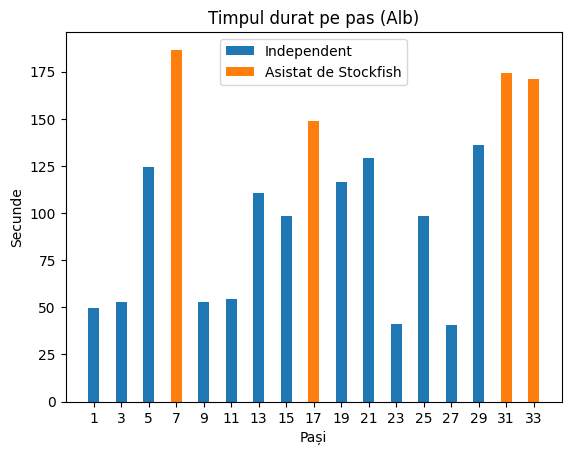

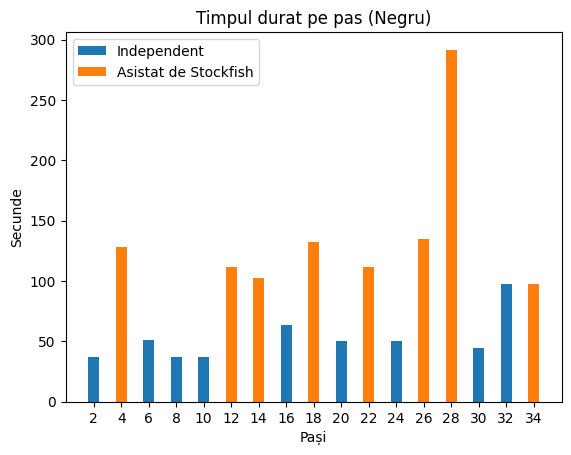

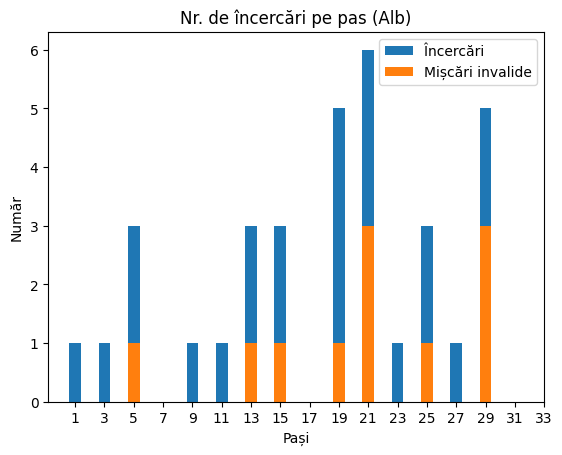

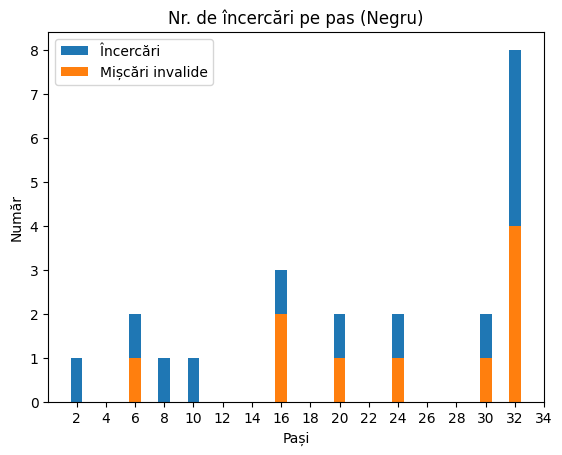

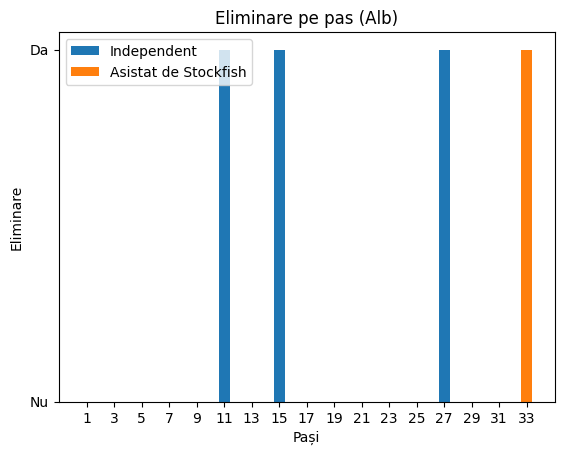

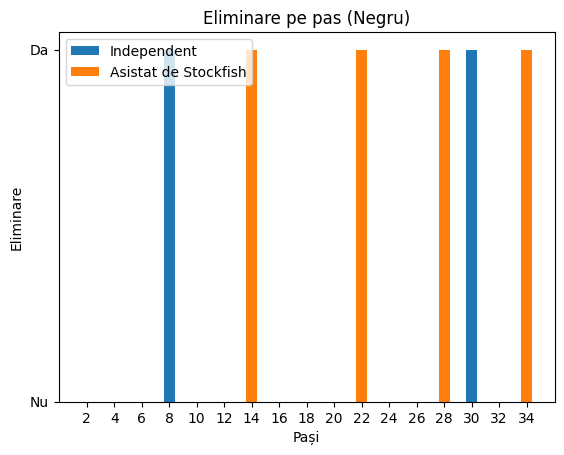

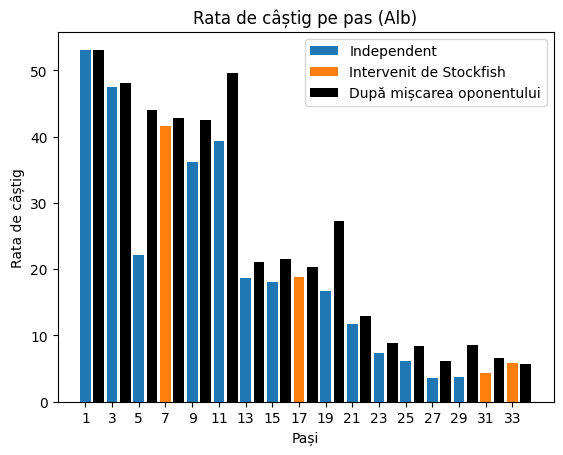

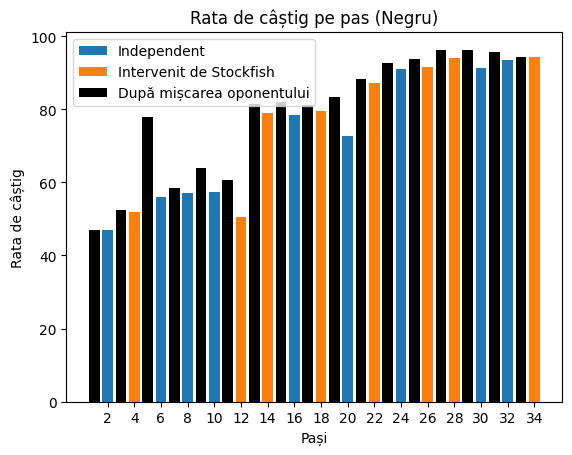

In [24]:
plot_telemetry('qwen vs gemma both with full step recall and reinforcement.json')

## Qwen vs Stockfish

### Qwen neajustat

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,d2d4,1,[],52.575175,51.641404,False
1,Stockfish,d7d5,1,[],47.516641,1.272544,False
2,qwen2.5vl:32b-q8_0,e2e4,1,[],45.684321,17.459481,False
3,Stockfish,c7c6,1,[],44.317434,1.258567,False
4,qwen2.5vl:32b-q8_0,f2f3,3,[d2d4],52.024037,37.275435,False
5,Stockfish,g8f6,1,[],45.136669,1.249094,False
6,qwen2.5vl:32b-q8_0,g2g4,8,"[g1f3, d2d4, f1g3]",45.684321,82.500788,False
7,Stockfish,d5e4,1,[],52.666974,1.240755,True
8,qwen2.5vl:32b-q8_0,e1e2,7,"[d2d4, d1h5]",18.318374,73.188054,False
9,Stockfish,e4f3,1,[],79.793147,1.247242,True


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,8.000,8.0,8.000000,8.000000
average,5.125,2.5,33.369654,60.205256
min,1.000,0.0,12.043437,17.459481
max,8.000,5.0,52.575175,82.516298
sum,41.000,20.0,266.957234,481.642046


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,86.34%,-72.16%,90.46%
InvalidMoves,86.34%,100.00%,-79.81%,77.61%
WinPercentage,-72.16%,-79.81%,100.00%,-62.07%
TimeTaken,90.46%,77.61%,-62.07%,100.00%


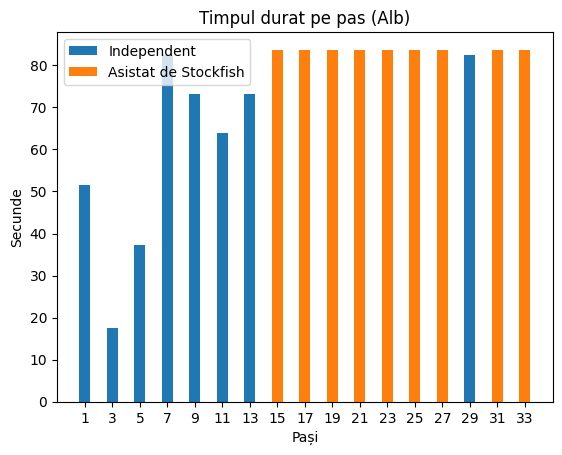

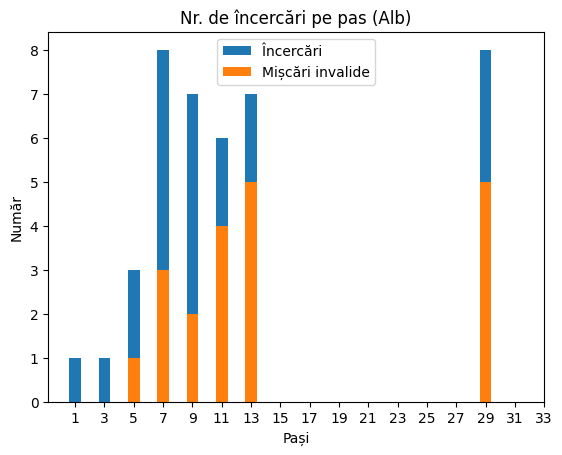

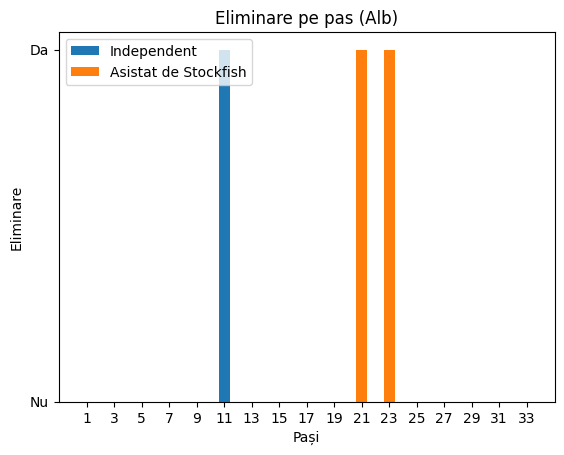

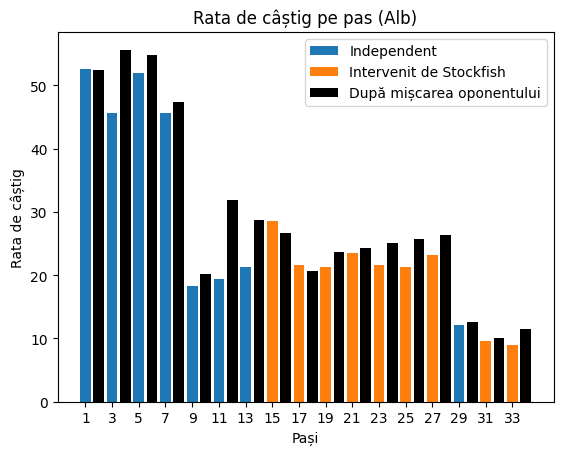

In [25]:
plot_telemetry('qwen stock.json', 'white')

### Qwen ajustat cu memorizare de mișcări anterioare

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,17.357164,False
1,Stockfish,e7e5,1,[],46.966016,1.271470,False
2,qwen2.5vl:32b-q8_0,g2g4,2,[],37.390714,68.257136,False
3,Stockfish,b8c6,1,[],56.950653,1.251539,False
4,qwen2.5vl:32b-q8_0,f2f4,1,[],9.958145,17.397521,False
5,Stockfish,e5f4,1,[],67.297855,1.237163,True
6,qwen2.5vl:32b-q8_0,g4g5,1,[],23.338204,17.359168,False
7,Stockfish,f8e7,1,[],73.424230,1.270182,False
8,qwen2.5vl:32b-q8_0,g5g6,1,[],11.470530,17.366465,False
9,Stockfish,e7h4,1,[],87.440225,1.212957,False


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,12.00,12.000000,12.000000,12.000000
average,2.75,1.083333,17.820332,37.130533
min,1.00,0.000000,2.368598,17.357164
max,6.00,4.000000,53.125687,68.257136
sum,33.00,13.000000,213.843989,445.566402


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,80.90%,-30.33%,81.56%
InvalidMoves,80.90%,100.00%,-42.42%,58.49%
WinPercentage,-30.33%,-42.42%,100.00%,-2.09%
TimeTaken,81.56%,58.49%,-2.09%,100.00%


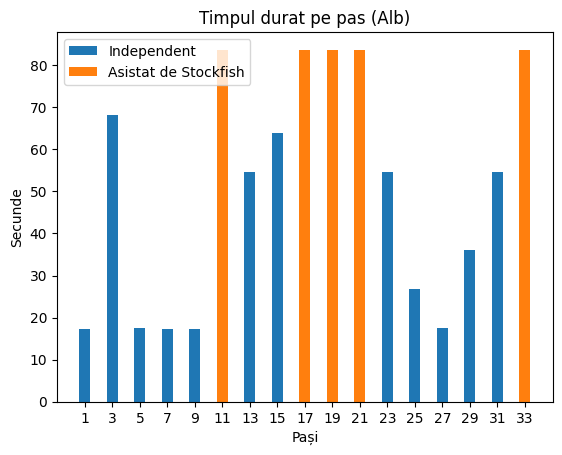

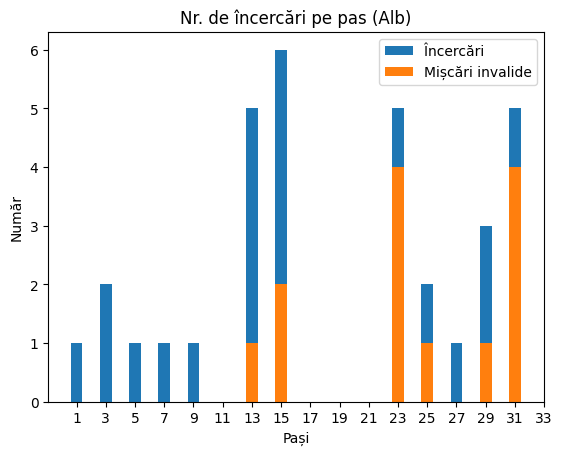

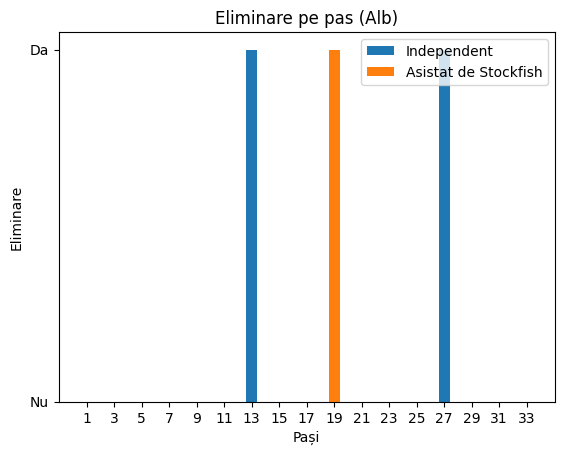

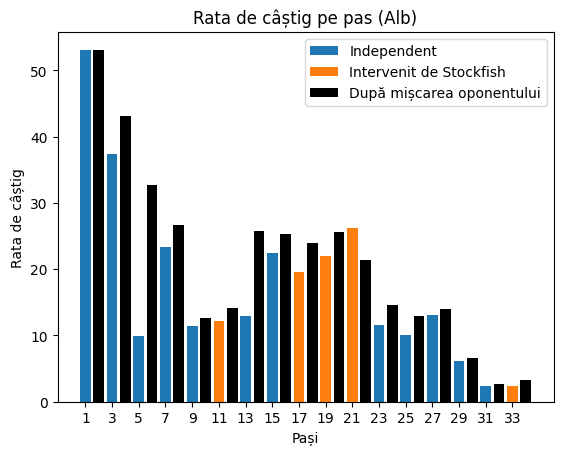

In [26]:
plot_telemetry('qwen with step recall.json', 'white')

### Qwen ajustat cu memorizare de mișcări anterioare + reinforcement după mișcările greșite

#### Lista mișcărilor

,Model,Move,AttemptCount,InvalidMoves,WinPercentage,TimeTaken,IsElimination
0,qwen2.5vl:32b-q8_0,e2e4,1,[],53.125687,18.308109,False
1,Stockfish,c7c5,1,[],47.241245,1.261011,False
2,qwen2.5vl:32b-q8_0,d2d4,4,[e2e4],52.299676,133.644609,False
3,Stockfish,g7g6,1,[],41.700770,1.243503,False
4,qwen2.5vl:32b-q8_0,g1f3,1,[],54.589644,17.363170,False
5,Stockfish,c5d4,1,[],47.149482,1.255288,True
6,qwen2.5vl:32b-q8_0,f3e5,1,[],23.404146,17.344226,False
7,Stockfish,b8c6,1,[],61.045228,1.243168,False
8,qwen2.5vl:32b-q8_0,e5f7,1,[],21.920289,17.320321,True
9,Stockfish,e8f7,1,[],78.268184,1.278730,True


#### Statistici

##### Statistici pentru Alb

,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
count,12.00,12.000000,12.000000,12.000000
average,2.75,0.833333,20.469390,66.082556
min,1.00,0.000000,0.922800,17.320321
max,8.00,3.000000,54.589644,150.890206
sum,33.00,10.000000,245.632677,792.990669


,AttemptCount,InvalidMoves,WinPercentage,TimeTaken
AttemptCount,100.00%,93.65%,-32.43%,93.55%
InvalidMoves,93.65%,100.00%,-40.94%,87.75%
WinPercentage,-32.43%,-40.94%,100.00%,-25.79%
TimeTaken,93.55%,87.75%,-25.79%,100.00%


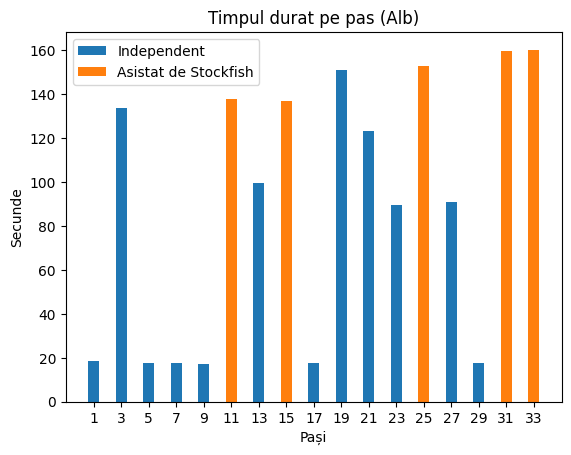

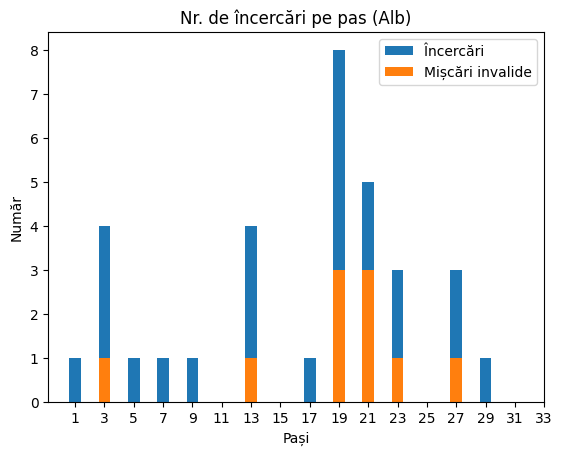

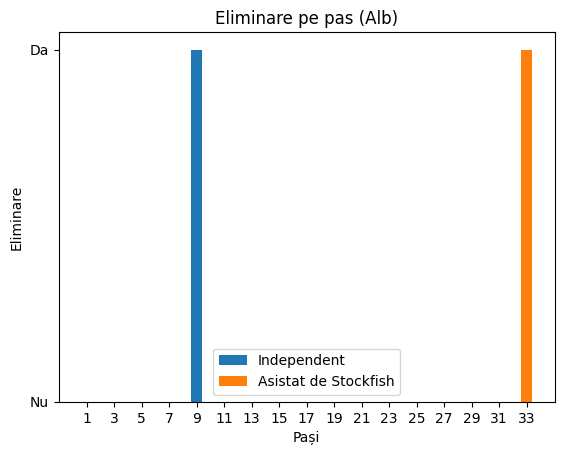

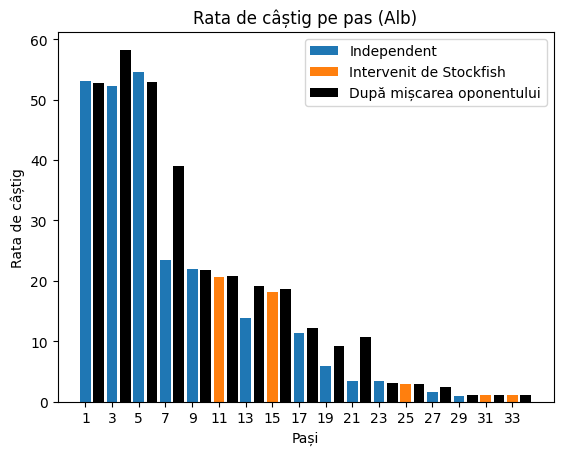

In [27]:
plot_telemetry('qwen with step recall and reinforcement.json', 'white')

## Concluzii

### Qwen vs Qwen

#### Ambele neajustate

- Ambele modele deseori depășesc nr. maxim de încercări, creând dependență de fallback la Stockfish.

#### Ambele ajustate cu memorizare de mișcări anterioare

- Mai puțină dependență de Stockfish, dar nr. de încercări tot rămân înalte.
- Alb a putut independent să facă 2 capturi.
  
#### Ambele ajustate cu reinforcement după mișcările greșite

- Mai mult timp durat pe pas, tot puțină dependendență de Stockfish.
- Fără intervenție de la Stockfish, Alb a făcut o captura, iar Negru - 2 capturi.

#### Ambele ajustate cu memorizare de mișcări anterioare + reinforcement după mișcările greșite (!!)

- Alb deloc nu a depins de Stockfish, dar a fost învins de Negru.
- Rata de câștig a lui Negru a crescut stabil până la victorie.
- Negru a fost ajutat de trei ori de Stockfish, unde ultima mișcare de victorie tot este intervenit de Stockfish.
- Pentru ambele părți, nr. de încercări sunt foarte scăzute, ceea ce indică un record.

#### Ambele ajustate cu memorizare de mișcări anterioare + informare despre mișcările oponentului (!)

- Nr. de încercări tot rămân înalte, dar am văzut mai multe eliminări din partea lui Alb fără intervenție de Stockfish.
- Alb este capabil să-și mențină probabilitatea de câștig înalt cu puțină intervenție de la Stockfish.
- Alb a capturat patru piese, fără ajutor de la Stockfish.
- Negru a capturat două piese, fără ajutor de la Stockfish.

#### Ambele ajustate cu memorizare de mișcări anterioare + reinforcement după mișcările greșite + informare despre mișcările oponentului (?!)

- Timpul pe încercări sunt înalte, dar nr. de încercări tot rămân înalte.
- Dependență mai frecventă de fallback la Stockfish.
- Se vede că ajustarea cu „lista neagră” nu ajută cu scăderea nr. de încercări.
  - De exemplu, aproximativ de șapte ori repetă aceeași mutare ilegală.
- Oricum, Alb își păstrează probabilitatea de câștig înalt cu puțin ajutor de la Stockfish.
- Negru a capturat două piese, fără ajutor de la Stockfish.

### Qwen vs Gemma

#### Ambele neajustate

- Qwen a fost asistat mult de Stockfish.
- Gemma practic a „trișat” tot timpul cu Stockfish (posibil din cauza că nu știa cum să scrie mutarea în formatul LAN).

#### Ambele ajustate cu memorizare de mișcări anterioare + reinforcement după mișcările greșite

- Qwen a fost asistat mai puțin de Stockfish, cu nr. de încercări joase.
- Gemma putea să facă independent mutări, dar a fost asistat cel mai mult de Stockfish.

#### Ambele ajustate cu memorizare de mișcări anterioare + informare despre mișcările oponentului

- Ambele modele au fost asistate deseori de Stockfish.
- Pentru primele mișcări, Gemma independent a putut face mutări cu nr. scăzut de încercări/timp scăzut.
- La un pas, a durat aproape 350 de secunde ca Gemma să facă o mutare.
- În midgame, ambele modele au avut timpul durat pe pas >100 secunde.
- Fără asistență de la Stockfish, ambele modele au avut 3 capturi.

#### Ambele ajustate cu memorizare de mișcări anterioare + reinforcement după mișcările greșite + informare despre mișcările oponentului

- La un pas, a durat aproape 350 de secunde ca Gemma să facă o mutare.
- Qwen a avut parte de mai puțină intervenție de la Stockfish, dar Gemma - foarte mult.
- Qwen a făcut 3 capturi autentice, 1 asistată de Stockfish.
- Gemma a făcut 2 capturi autentice, 4 asistate de Stockfish.
- Rata de câștig a lui Gemma crește, deoarece este mai mult asistat de Stockfish.

### Qwen vs Stockfish

Evident că probabilitatea de câștig a lui Qwen scade din cauza că se joacă împotriva unui motor puternic

#### Qwen neajustat

În midgame, Qwen a fost aproape asistat tot timpul de Stockfish.

#### Qwen ajustat cu memorizare de mișcări anterioare

Qwen a capturat indepentent două piese.

#### Qwen ajustat cu memorizare de mișcări anterioare + reinforcement după mișcările greșite

Straniu că „lista neagră” a dus la o scădere la performanța lui Qwen. Mai mult timp pe încercare, mai puține capturi.